In [46]:
import pandas as pd

# 파일 경로 설정
csv_path = 'C:/Users/acorn/Documents/python/일별소매가/단감_상품_10개_일별소매가.csv'
xlsx_path = 'C:/Users/acorn/Downloads/단감_상품_10개_일별소매가.xlsx'

# 데이터 로드
csv_data = pd.read_csv(csv_path, encoding='cp949')
xlsx_data = pd.read_excel(xlsx_path)

# 날짜 열 처리 (csv와 xlsx 모두)
csv_data['구분'] = pd.to_datetime(csv_data['구분'])
xlsx_data['구분'] = pd.to_datetime(xlsx_data['구분 '])

# xlsx에 없는 날짜를 확인
valid_dates = set(xlsx_data['구분'])  # 유효한 날짜 집합
csv_data['Valid'] = csv_data['구분'].isin(valid_dates)  # 유효 여부 확인

# 연속적으로 9일 이상 비어 있는 날짜의 데이터를 삭제
csv_data['Gap'] = csv_data['Valid'].astype(int).diff().fillna(0).cumsum()
grouped = csv_data.groupby('Gap')
filtered_data = pd.concat([
    group for _, group in grouped 
    if group['Valid'].sum() > 0 or len(group) <= 9
])

# 결과 저장
output_path = 'C:/Users/acorn/Documents/python/단감_상품_10개_일별소매가_정제.csv'
filtered_data.drop(columns=['Valid', 'Gap'], inplace=True)  # 임시 열 제거
filtered_data.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"정제된 데이터가 '{output_path}'로 저장되었습니다.")

정제된 데이터가 'C:/Users/acorn/Documents/python/단감_상품_10개_일별소매가_정제.csv'로 저장되었습니다.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import os

# Matplotlib 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [15]:
# 처리할 CSV 파일 목록 (파일 경로 리스트)
file_list = [
    'C:/Users/acorn/Documents/python/일별소매가/감자_중품_100g_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/감자_상품_100g_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/건고추_상품_600g_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/고구마_상품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/고구마_중품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/깐마늘_상품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/깐마늘_중품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/단감_상품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/단감_중품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/당근_상품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/당근_중품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/대파_상품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/대파_중품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/무_상품_1개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/무_중품_1개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/배_상품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/배_중품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/배추_상품_1포기_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/배추_중품_1포기_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/사과_상품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/사과_중품_10개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/수박_상품_1개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/수박_중품_1개_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/시금치_상품_100g_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/쌀_상품_20kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/양배추_상품_1포기_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/양배추_중품_1포기_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/양파_상품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/양파_중품_1kg_일별소매가.csv',
    'C:/Users/acorn/Documents/python/일별소매가/오이_상품_10개_일별소매가.csv'
]

# 결과 저장 디렉토리
output_dir = 'C:/Users/acorn/Documents/python/일별소매가/결과'
os.makedirs(output_dir, exist_ok=True)  # 디렉토리가 없으면 생성

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\감자_중품_100g_일별소매가_과거+예측데이터.csv


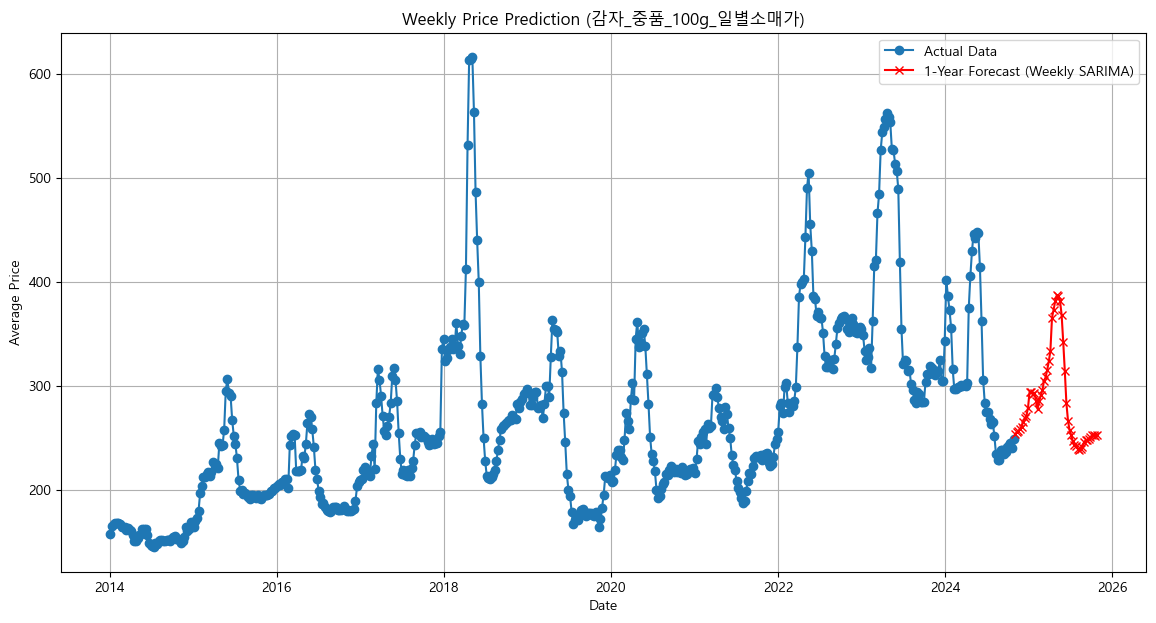

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\감자_상품_100g_일별소매가_과거+예측데이터.csv


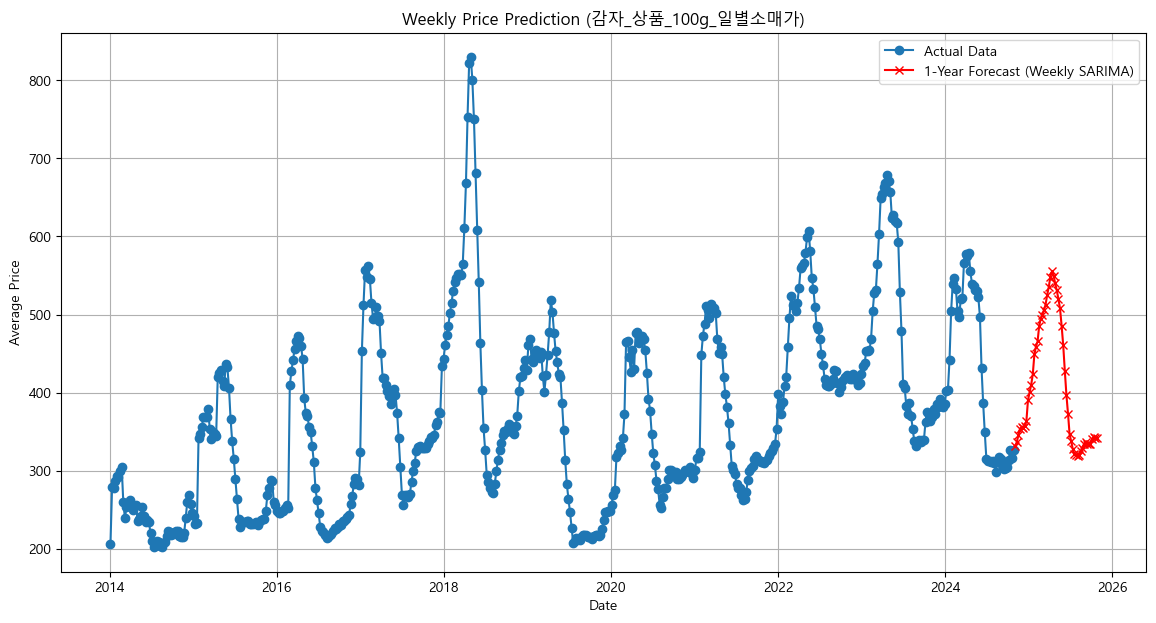

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\건고추_상품_600g_일별소매가_과거+예측데이터.csv


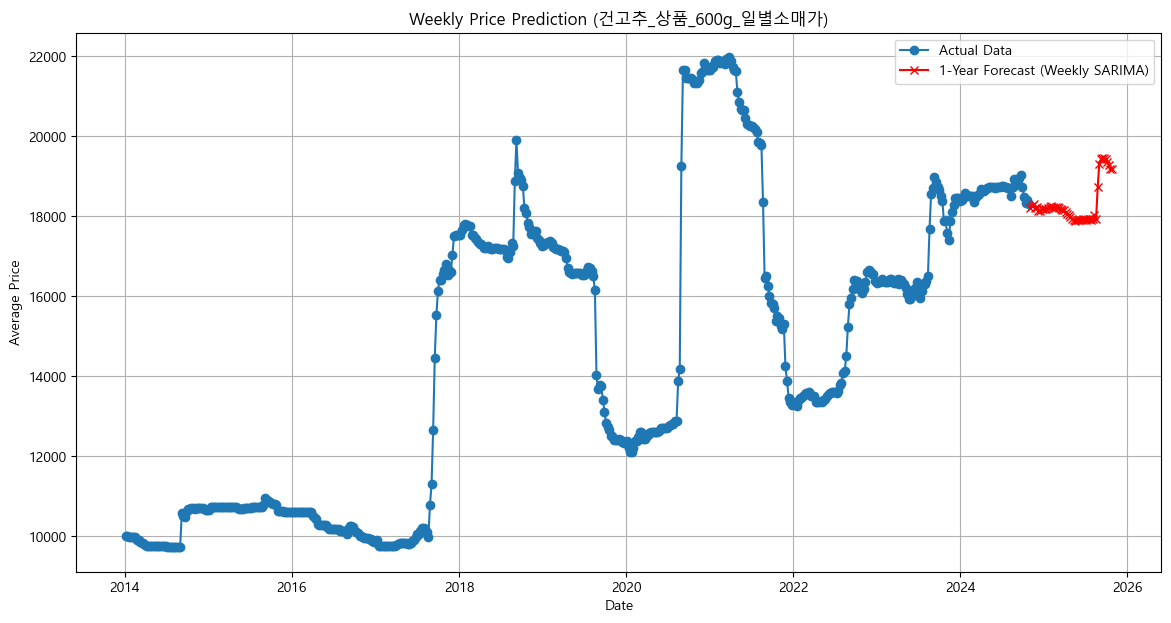

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\고구마_상품_1kg_일별소매가_과거+예측데이터.csv


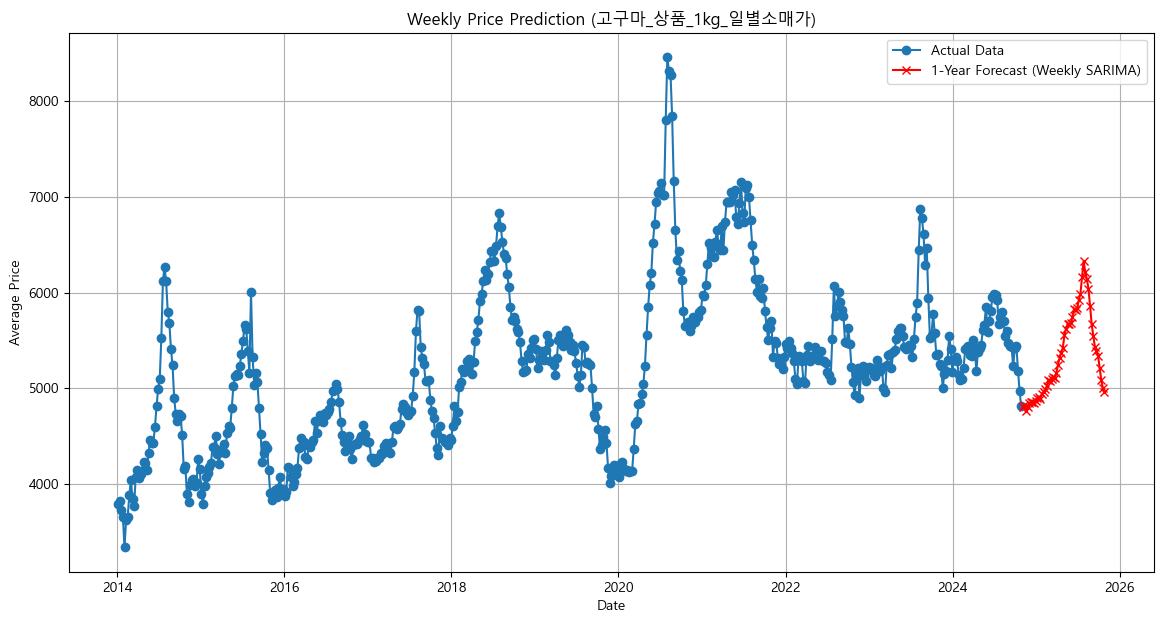

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\고구마_중품_1kg_일별소매가_과거+예측데이터.csv


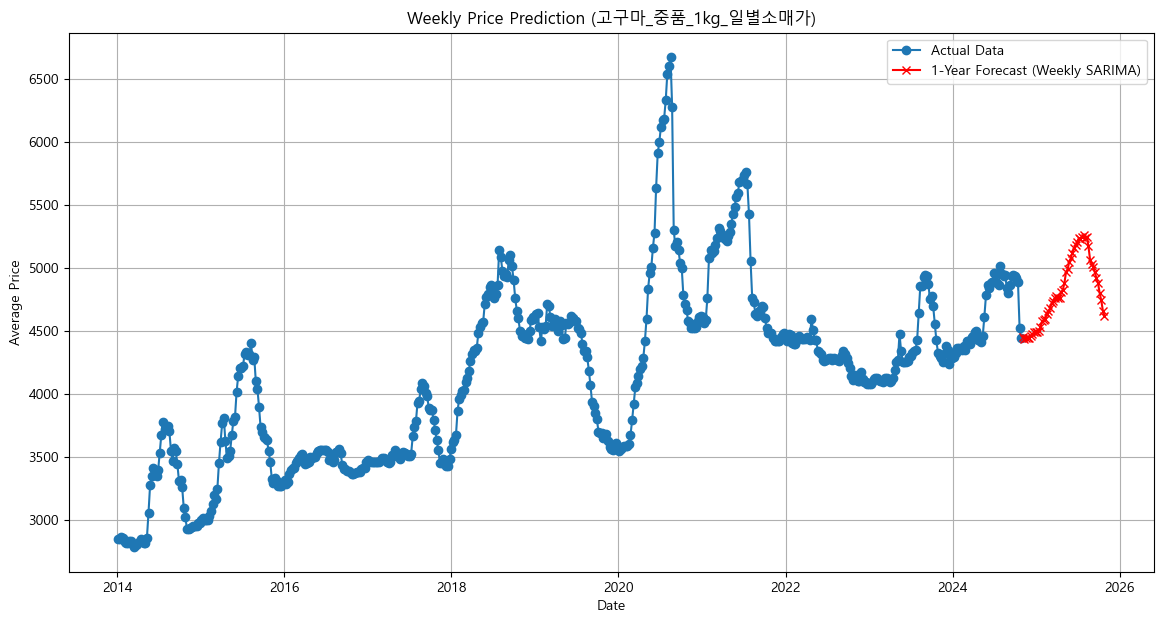

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\깐마늘_상품_1kg_일별소매가_과거+예측데이터.csv


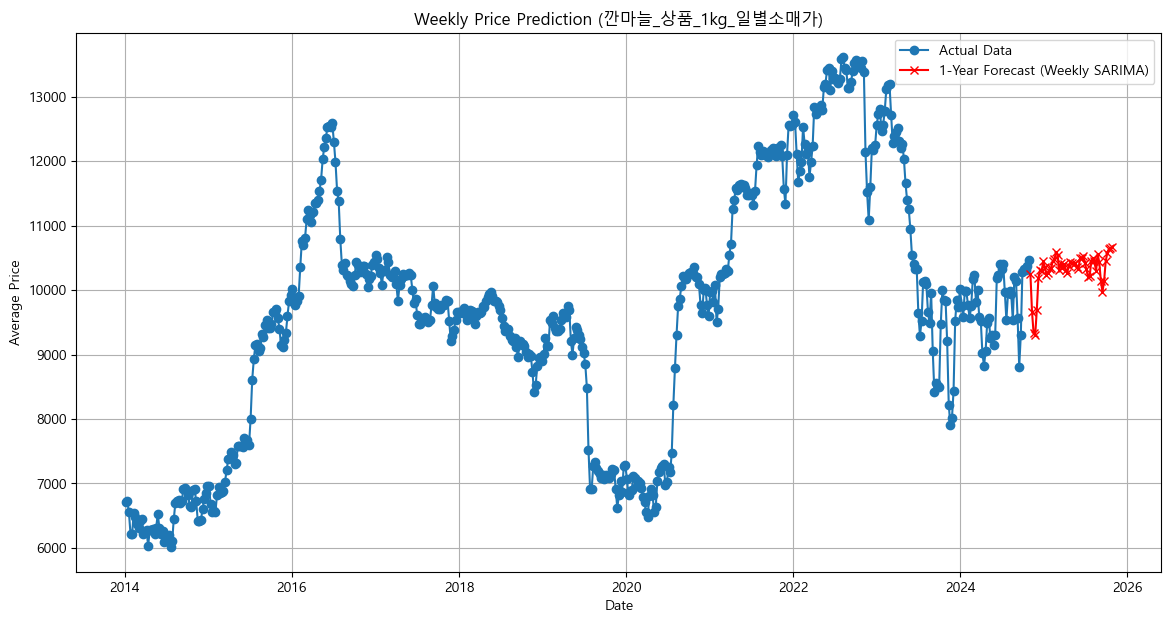

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\깐마늘_중품_1kg_일별소매가_과거+예측데이터.csv


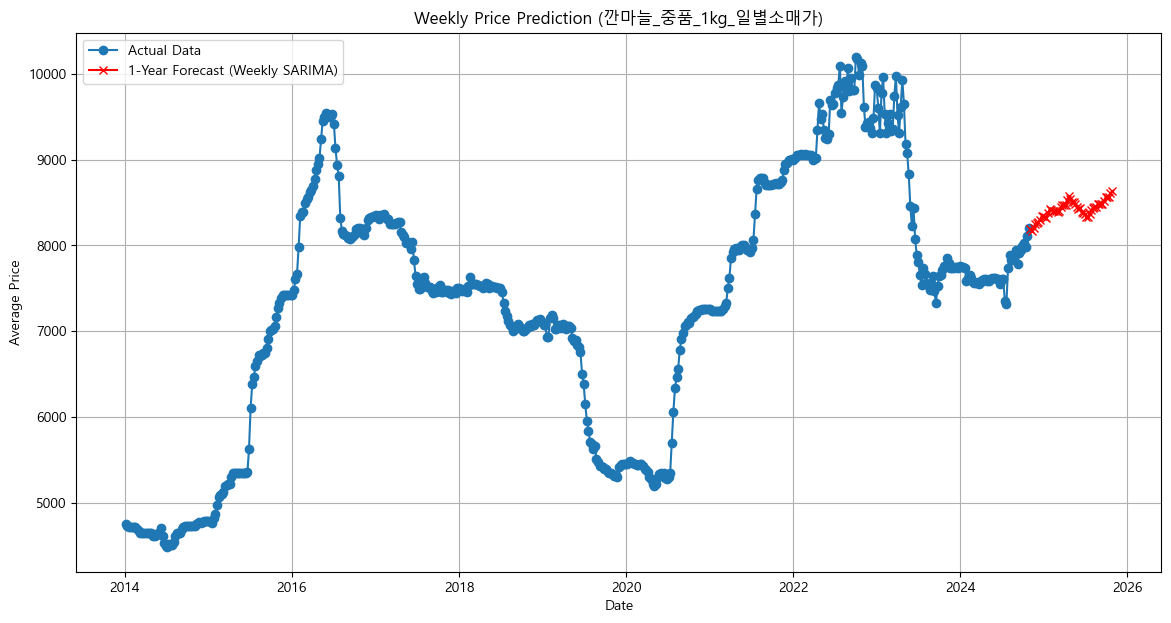

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\단감_상품_10개_일별소매가_과거+예측데이터.csv


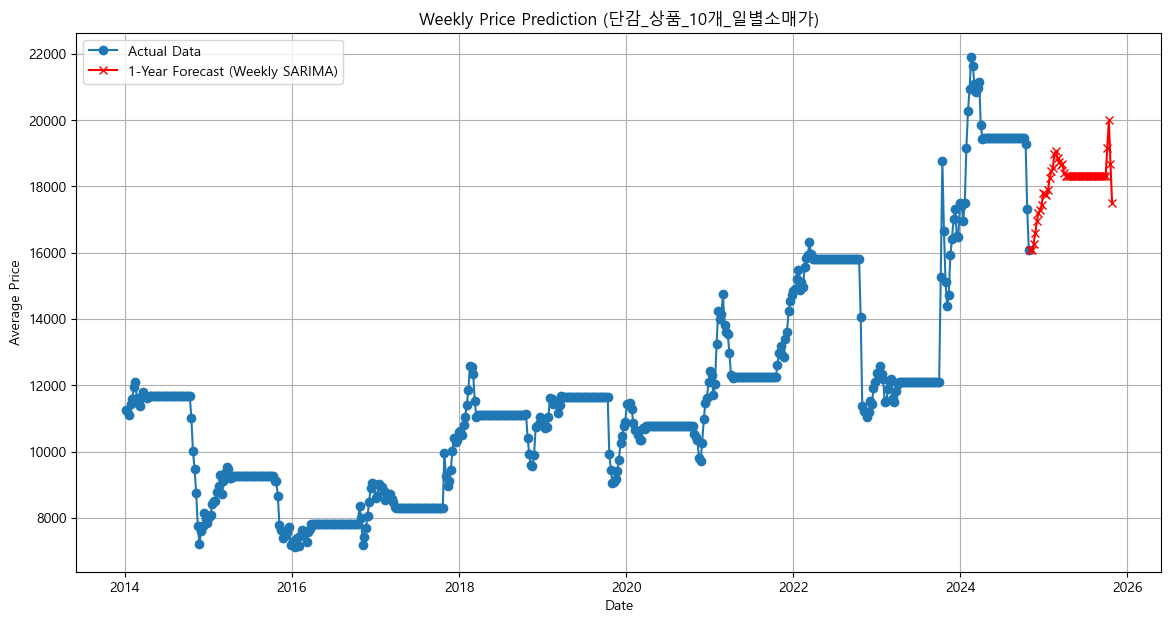

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\단감_중품_10개_일별소매가_과거+예측데이터.csv


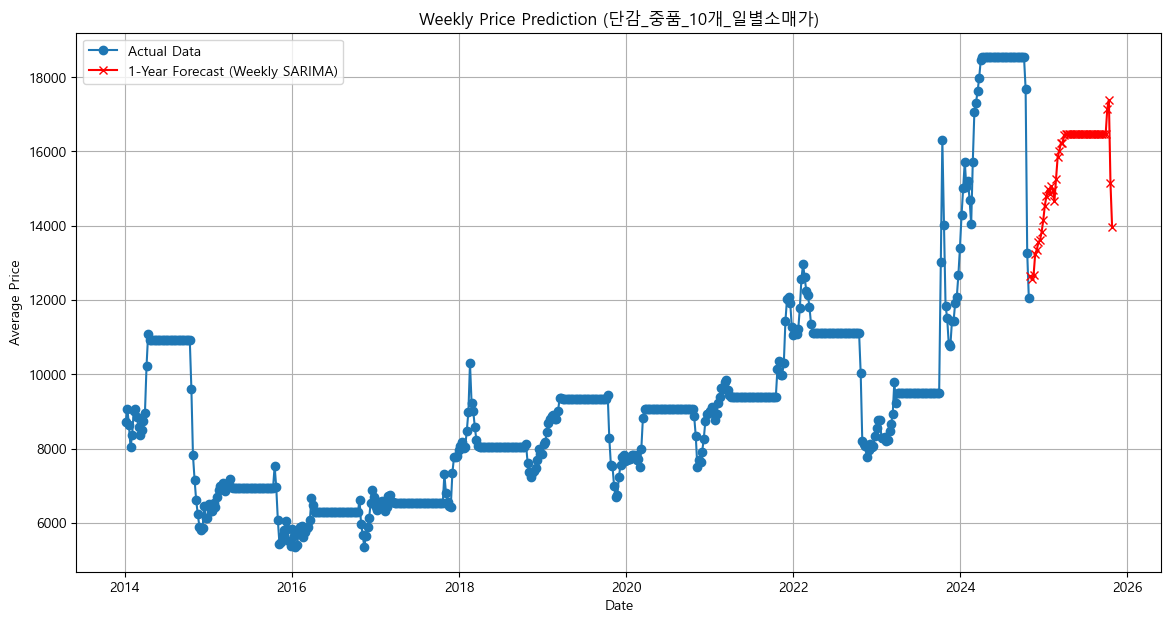

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\당근_상품_1kg_일별소매가_과거+예측데이터.csv


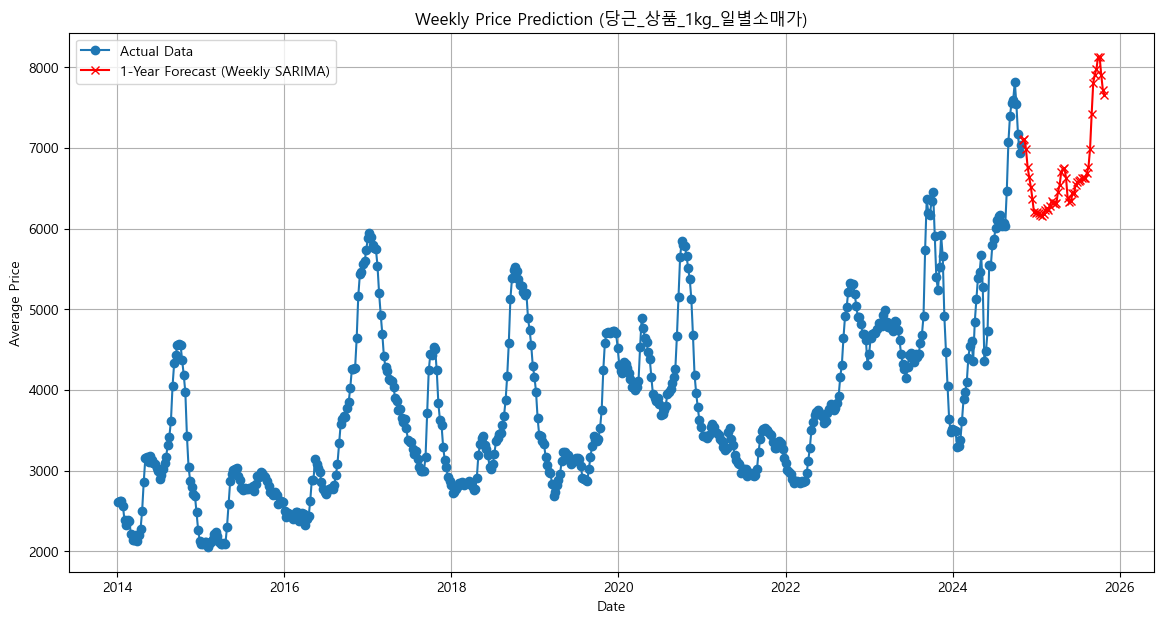

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\당근_중품_1kg_일별소매가_과거+예측데이터.csv


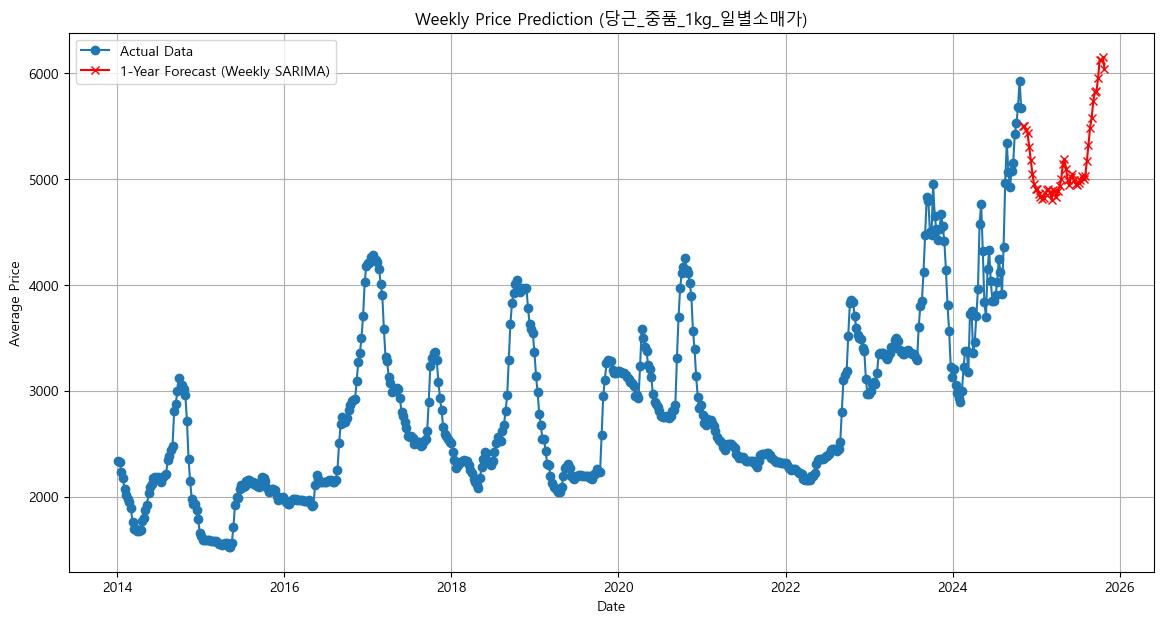

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\대파_상품_1kg_일별소매가_과거+예측데이터.csv


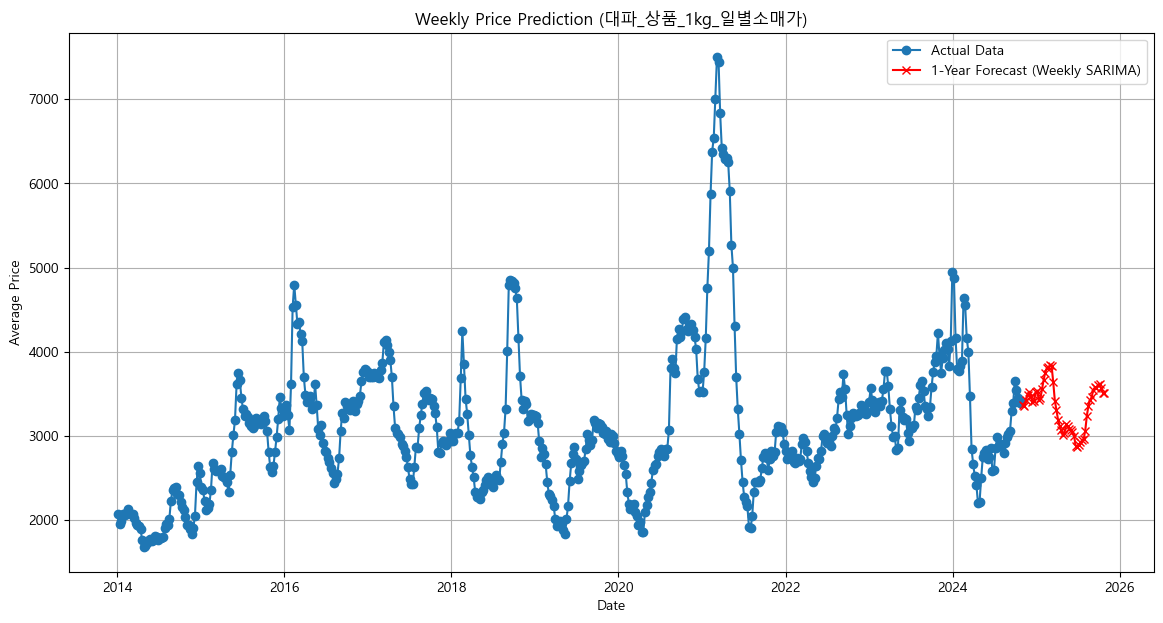

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\대파_중품_1kg_일별소매가_과거+예측데이터.csv


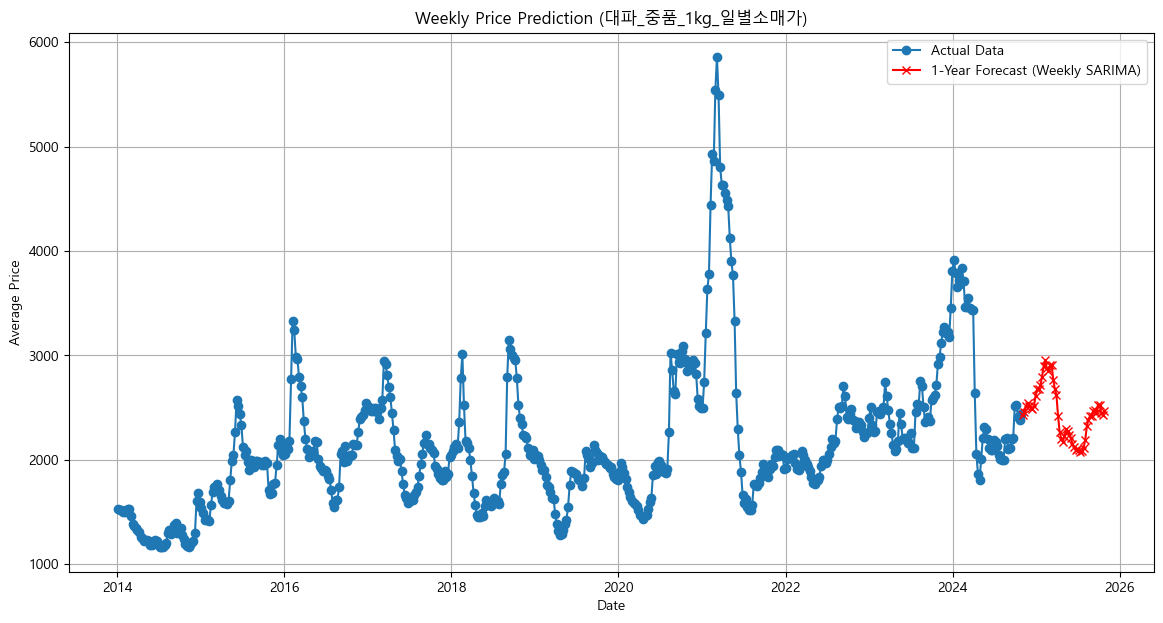

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\무_상품_1개_일별소매가_과거+예측데이터.csv


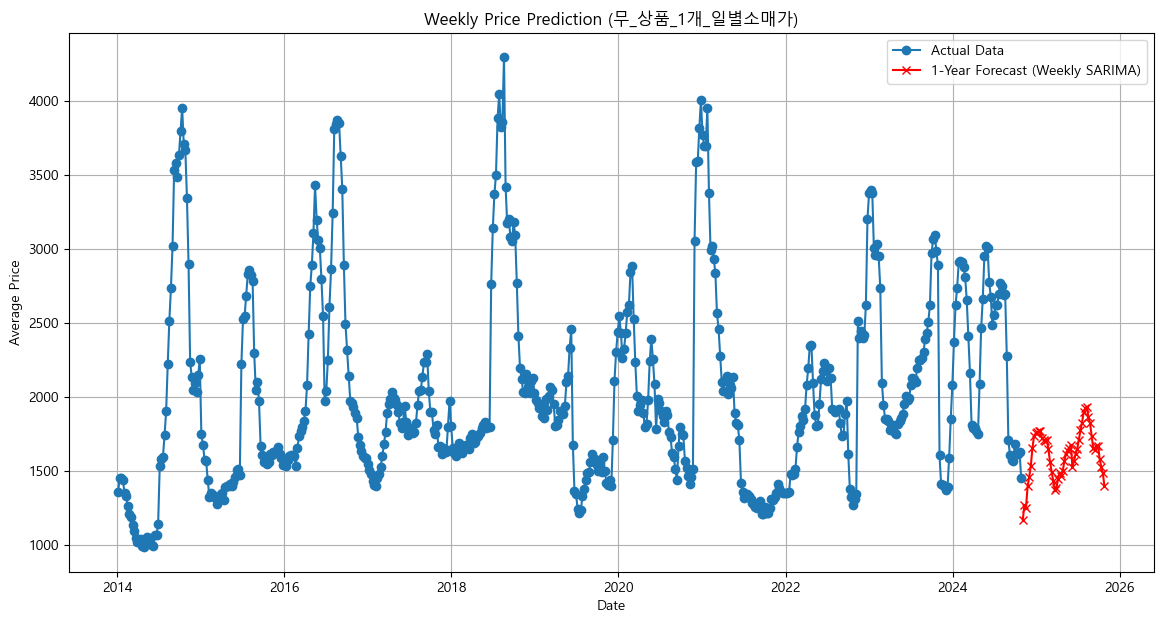

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\무_중품_1개_일별소매가_과거+예측데이터.csv


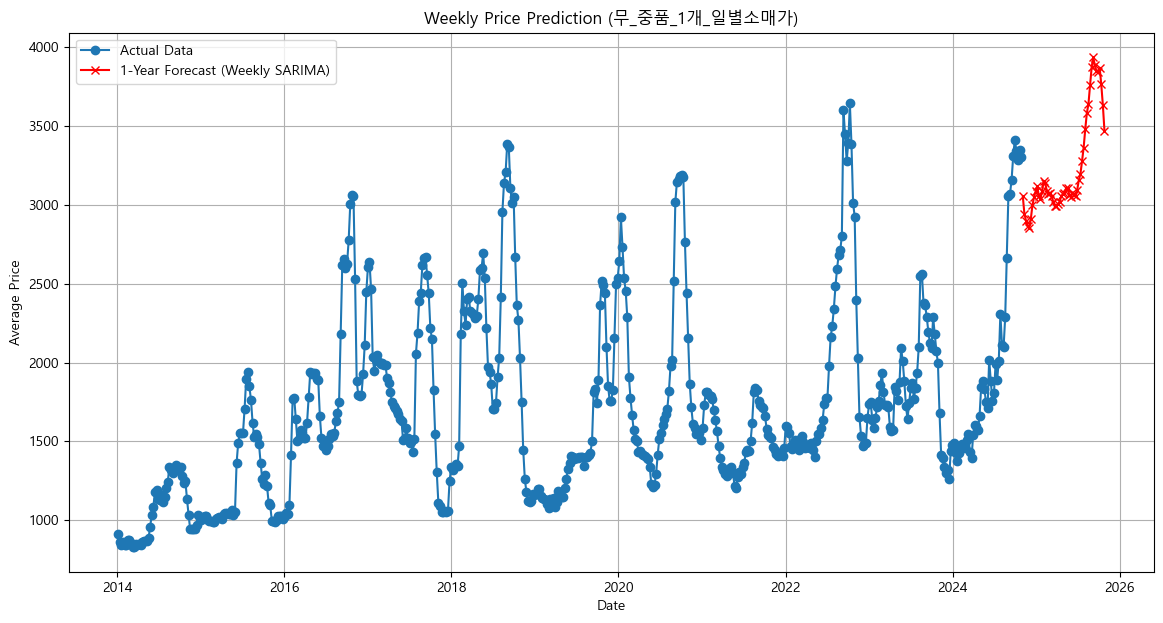

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\배_상품_10개_일별소매가_과거+예측데이터.csv


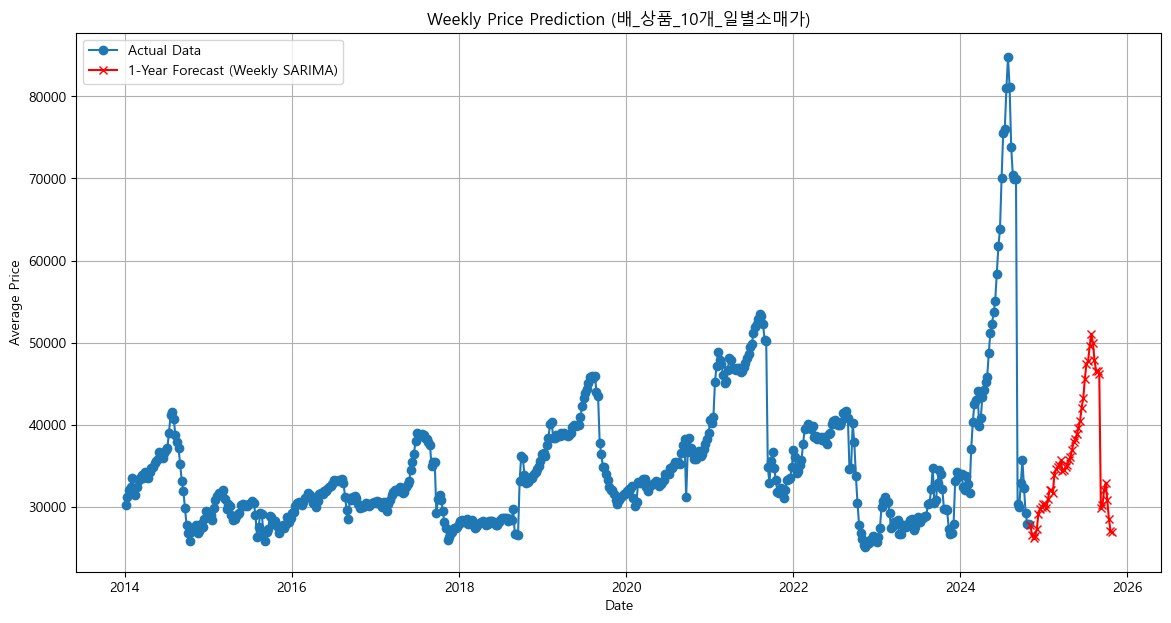

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\배_중품_10개_일별소매가_과거+예측데이터.csv


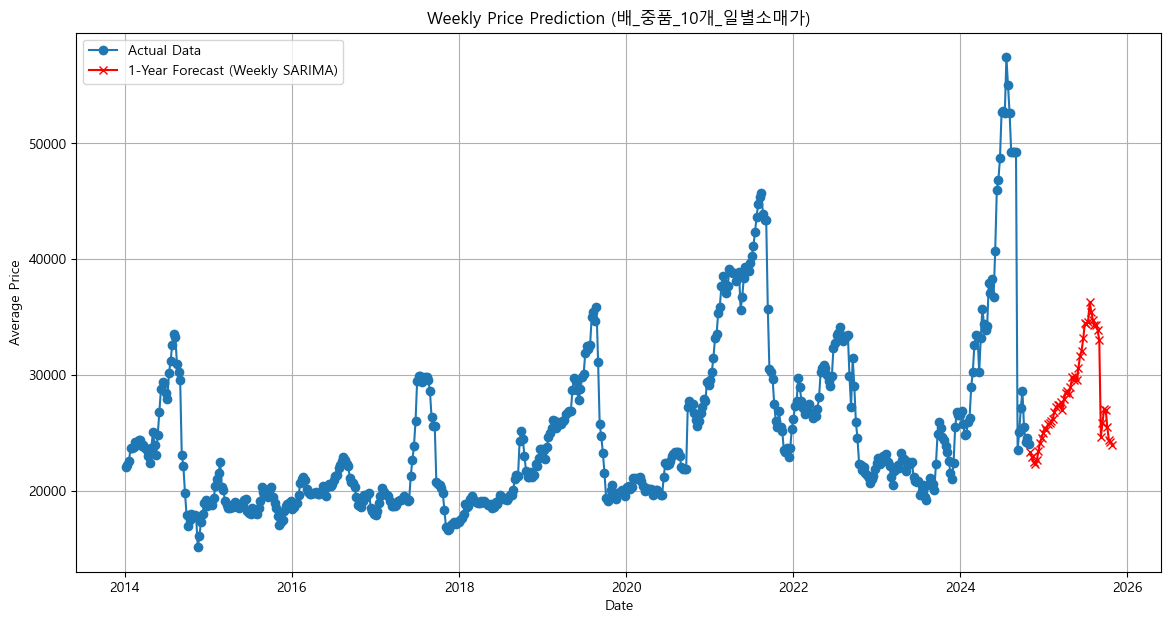

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
C:\Users\acorn\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\배추_상품_1포기_일별소매가_과거+예측데이터.csv


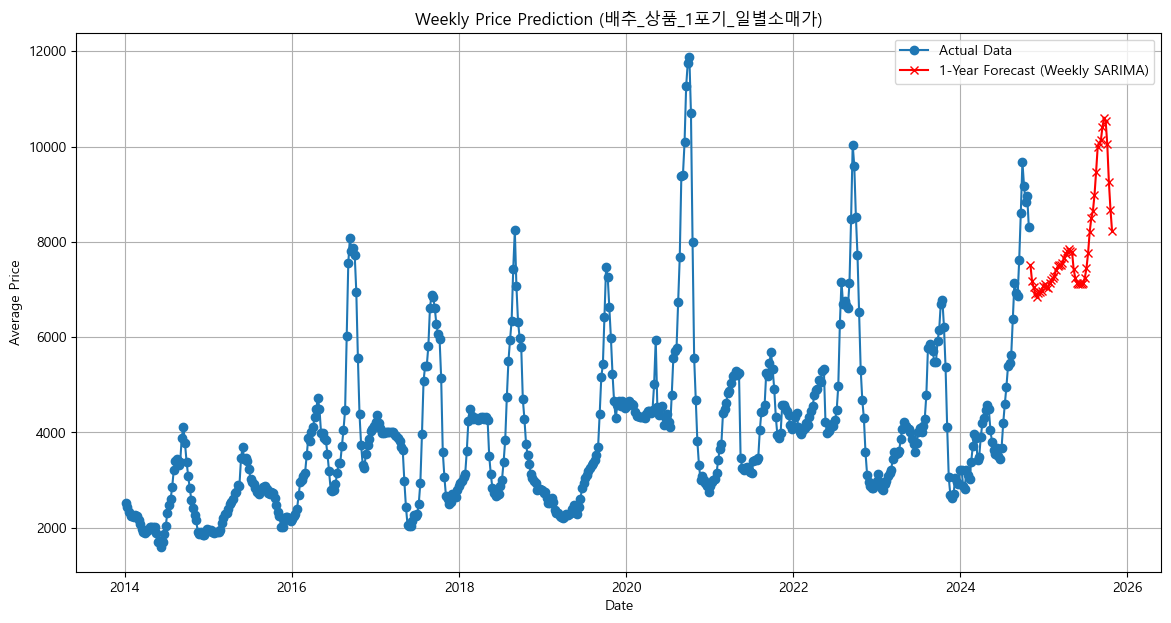

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
C:\Users\acorn\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\배추_중품_1포기_일별소매가_과거+예측데이터.csv


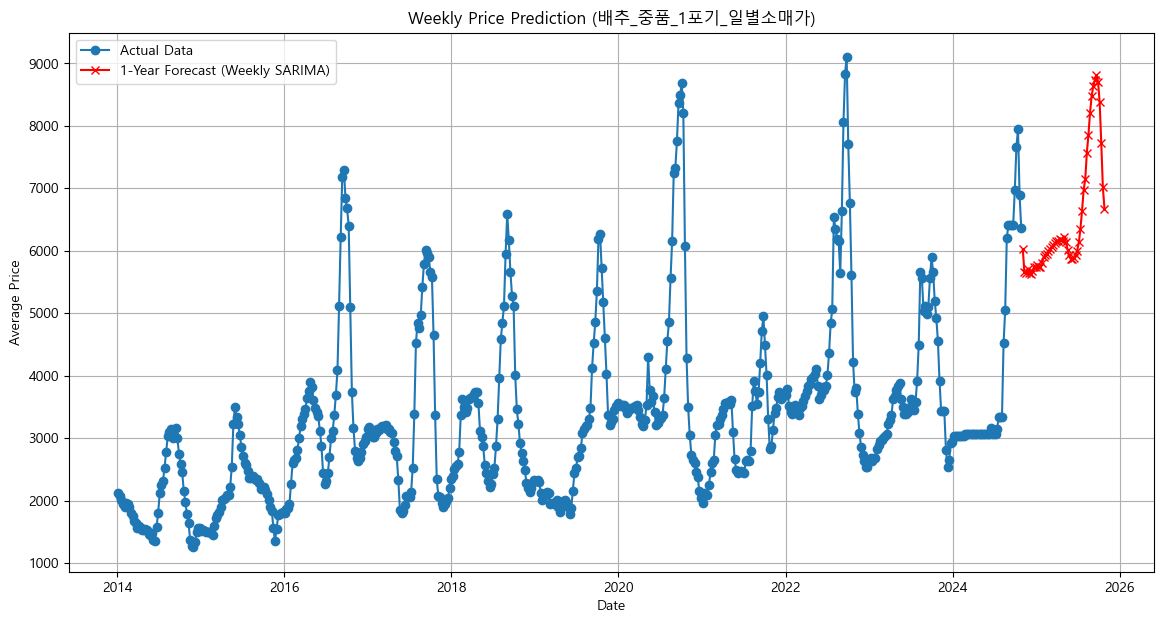

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\사과_상품_10개_일별소매가_과거+예측데이터.csv


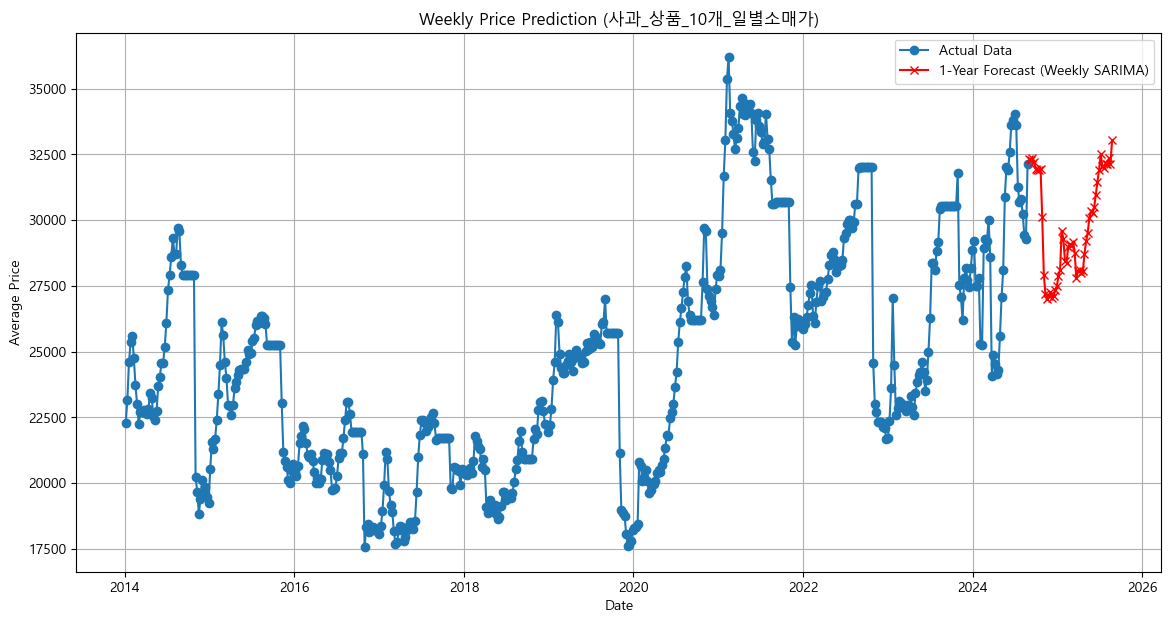

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\사과_중품_10개_일별소매가_과거+예측데이터.csv


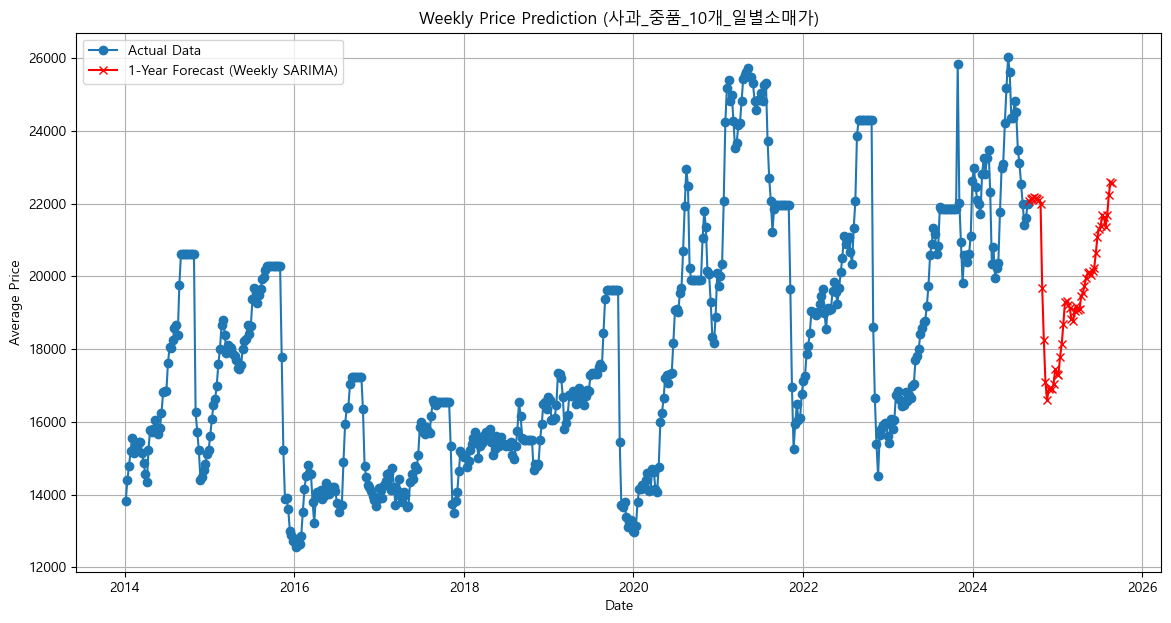

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\수박_상품_1개_일별소매가_과거+예측데이터.csv


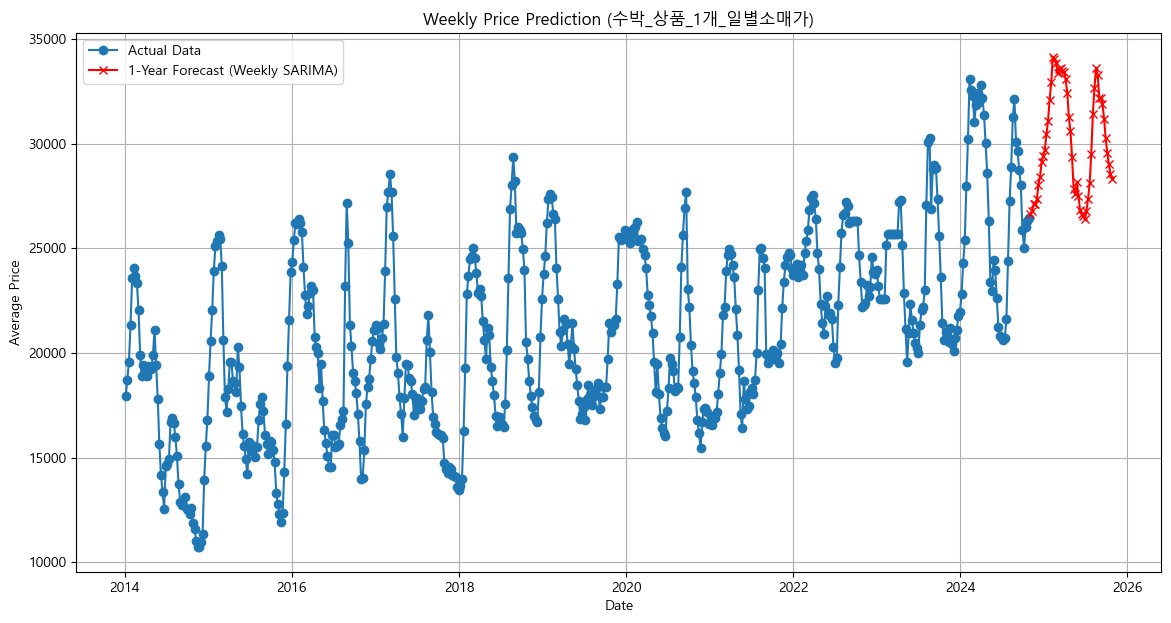

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\수박_중품_1개_일별소매가_과거+예측데이터.csv


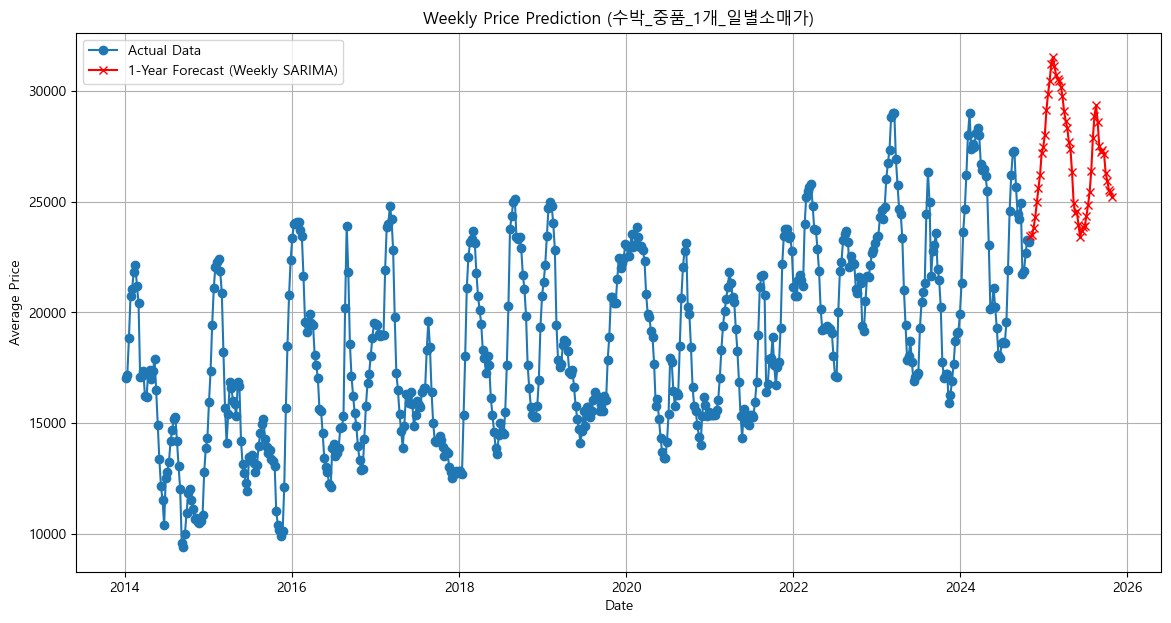

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\시금치_상품_100g_일별소매가_과거+예측데이터.csv


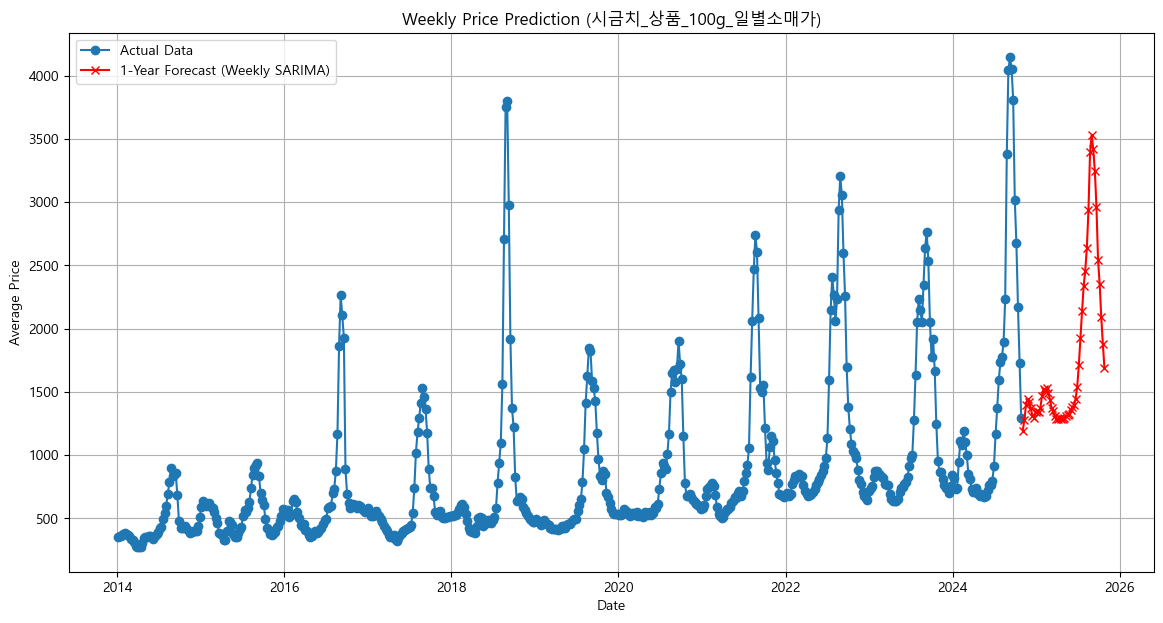

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\쌀_상품_20kg_일별소매가_과거+예측데이터.csv


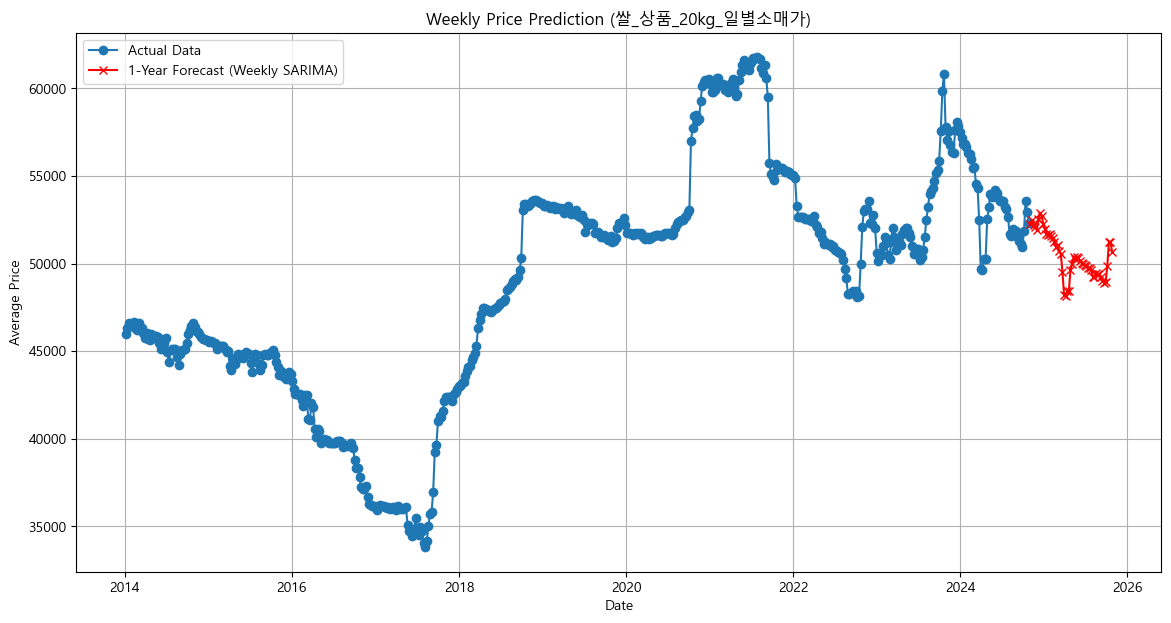

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\양배추_상품_1포기_일별소매가_과거+예측데이터.csv


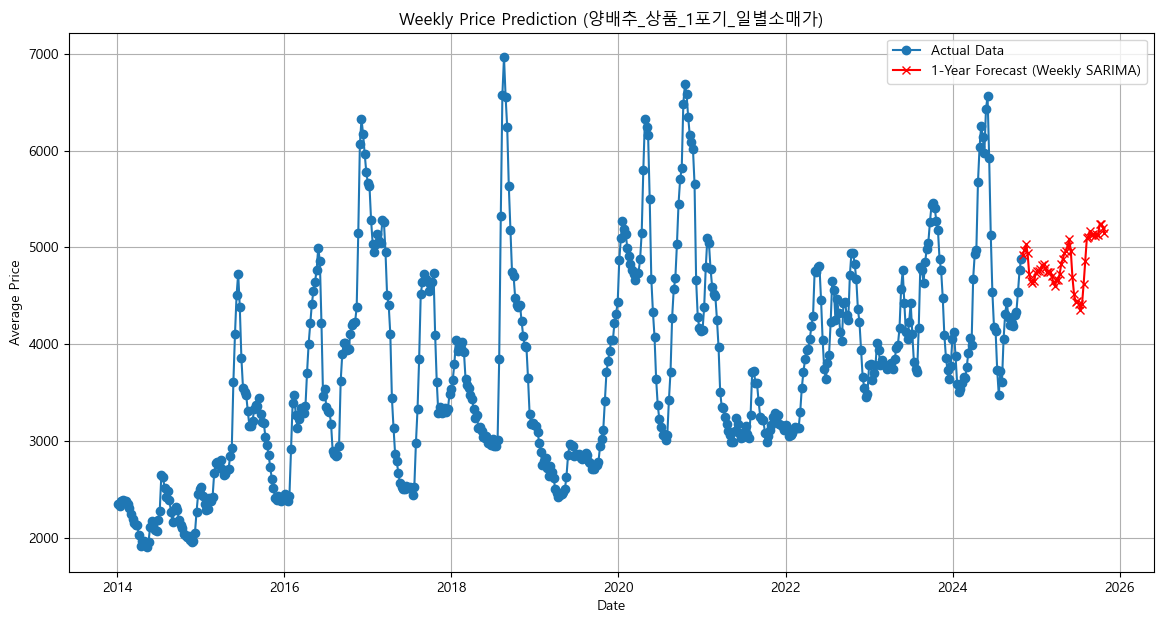

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\양배추_중품_1포기_일별소매가_과거+예측데이터.csv


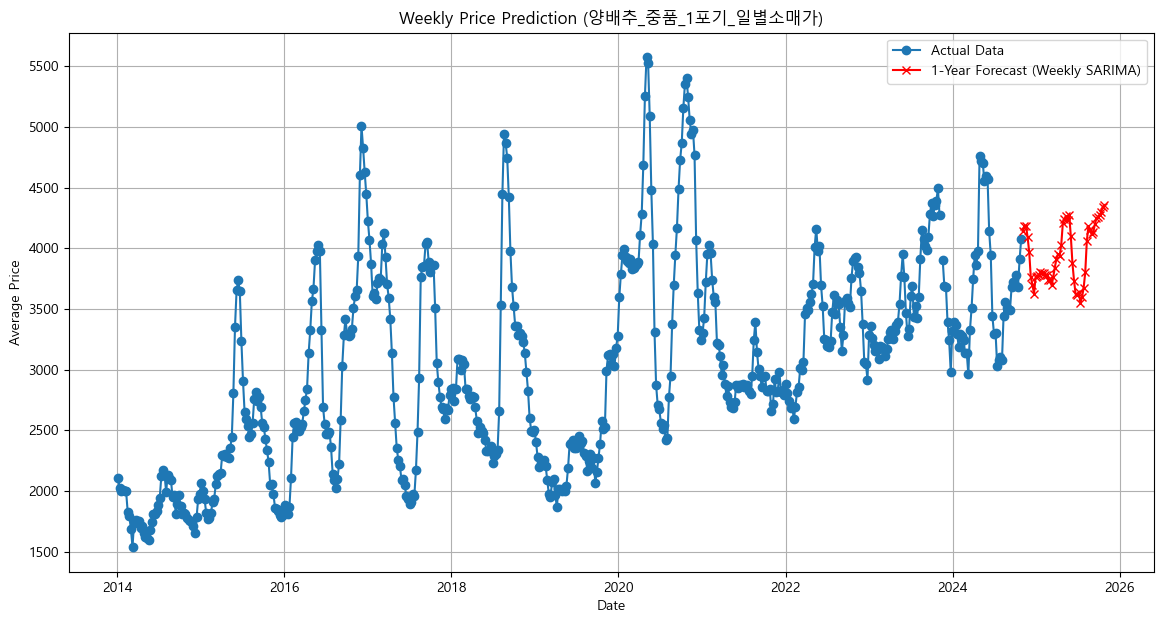

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\양파_상품_1kg_일별소매가_과거+예측데이터.csv


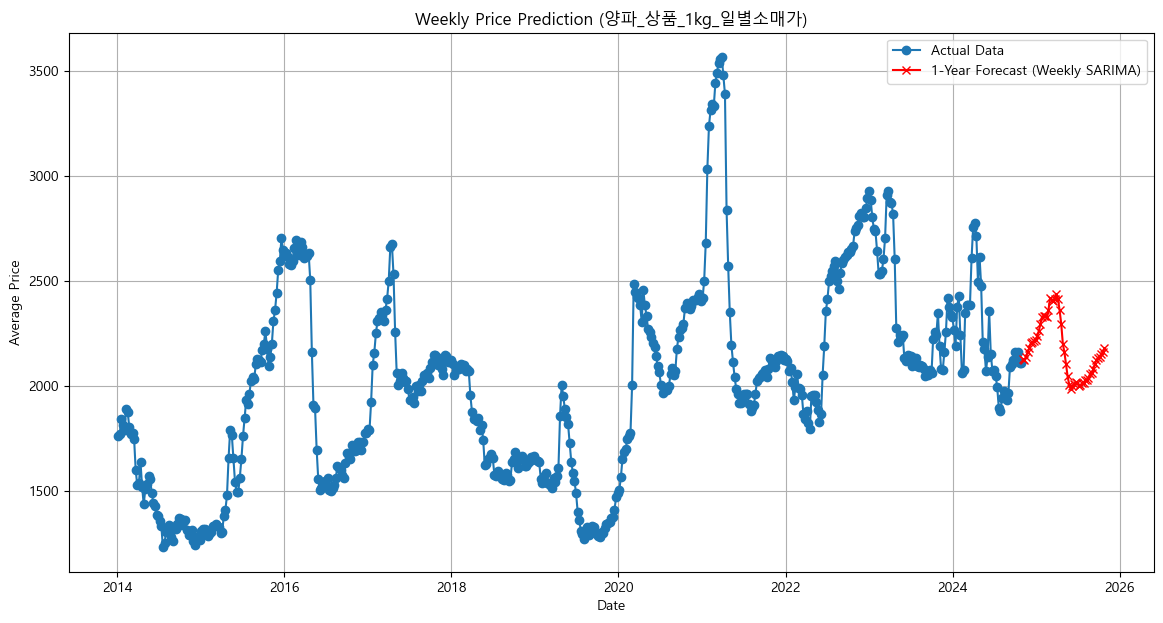

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\양파_중품_1kg_일별소매가_과거+예측데이터.csv


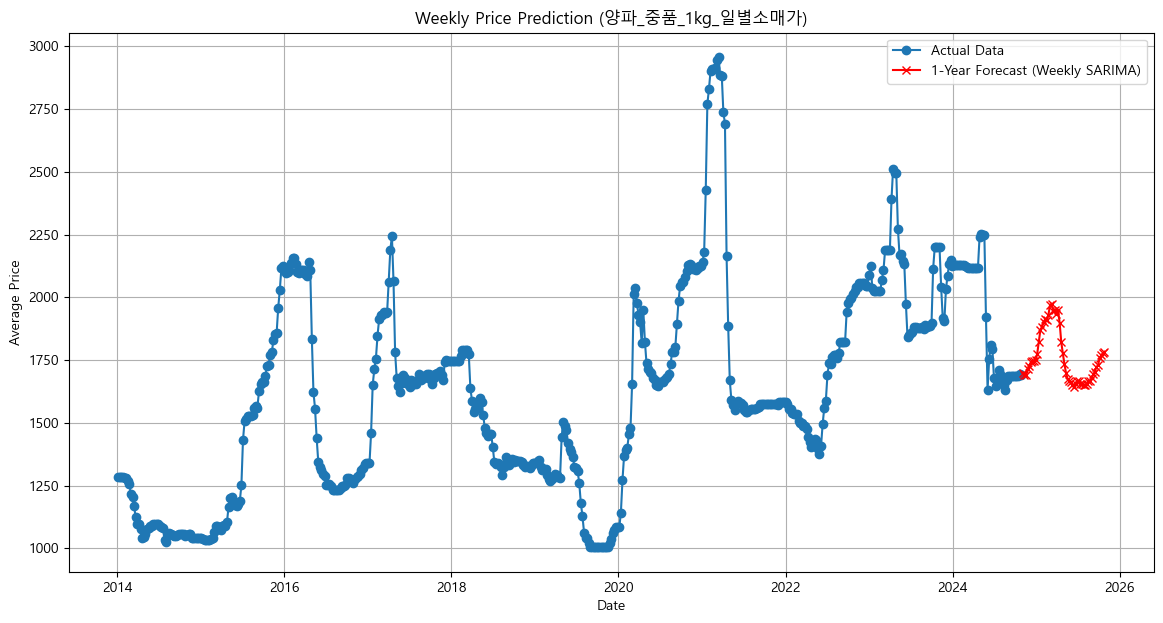

C:\Users\acorn\AppData\Local\Temp\ipykernel_8524\4066584554.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\오이_상품_10개_일별소매가_과거+예측데이터.csv


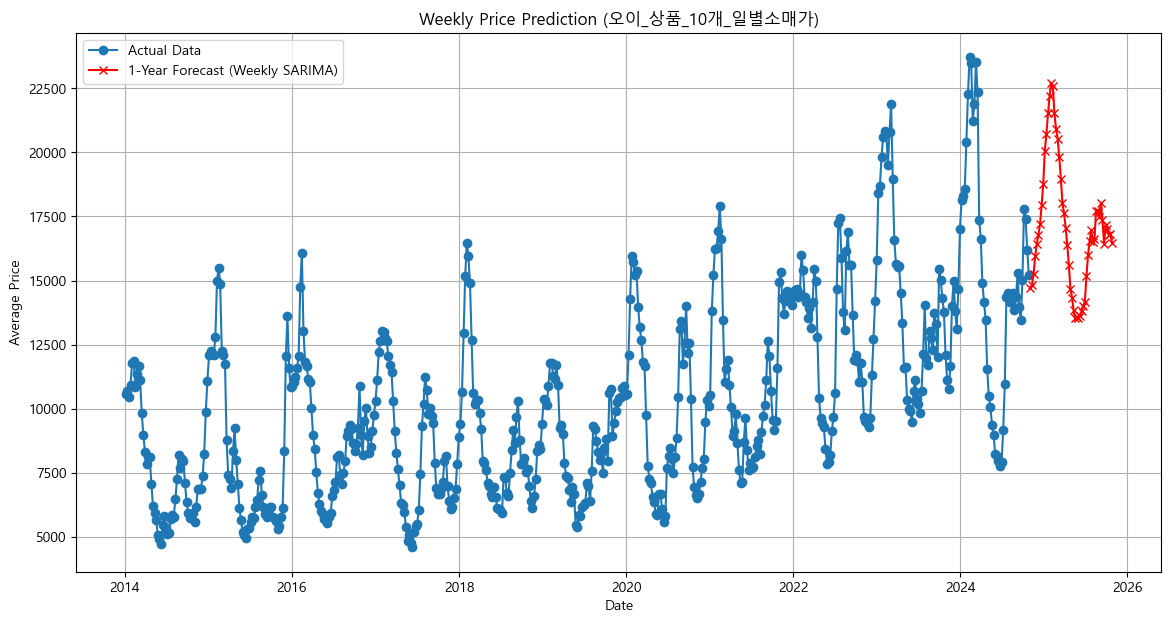

In [17]:
# 각 파일 반복 처리
for file_path in file_list:
    # 파일 이름 추출 (예: 감자_중품_100g_일별소매가)
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    
    # 데이터 로드
    data = pd.read_csv(file_path, encoding='cp949')
    
     # 쉼표 제거 처리 (숫자 변환)
    if data['평균'].dtype == 'object':
        data['평균'] = data['평균'].str.replace(',', '').astype(float)
        
    # 날짜 변환 및 데이터 준비
    data['구분'] = pd.to_datetime(data['구분'])
    data.set_index('구분', inplace=True)
    daily_prices = data['평균']
    
    # 결측치 처리 (필요시)
    daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
    
    # 주별 평균 데이터 생성
    weekly_prices = daily_prices.resample('W').mean()
    
    # SARIMA 모델 학습
    model = SARIMAX(weekly_prices, order=(5, 1, 0), seasonal_order=(1, 1, 1, 52))
    fitted_model = model.fit()
    
    # 1년(52주) 예측
    forecast = fitted_model.get_forecast(steps=52)
    forecast_values = forecast.predicted_mean
    
    # 예측 결과를 DataFrame으로 저장
    forecast_index = pd.date_range(start=weekly_prices.index[-1] + pd.DateOffset(weeks=1), 
                                   periods=52, freq='W')
    forecast_df = pd.DataFrame({
        'Date': forecast_index,
        'Price': forecast_values.values
    })
    
    # 과거 데이터와 예측 데이터 결합
    combined_df = pd.concat([
        pd.DataFrame({'Date': weekly_prices.index, 'Price': weekly_prices.values}),  # 과거 데이터
        forecast_df  # 예측 데이터
    ])
    
    # CSV 파일로 저장
    output_file = os.path.join(output_dir, f'{file_name}_과거+예측데이터.csv')
    combined_df.to_csv(output_file, index=False, encoding='cp949')
    print(f"파일 저장 완료: {output_file}")
    
    # 시각화
    plt.figure(figsize=(14, 7))
    plt.plot(weekly_prices, label='Actual Data', marker='o')
    plt.plot(forecast_index, forecast_values, label='1-Year Forecast (Weekly SARIMA)', color='red', marker='x')
    plt.title(f'Weekly Price Prediction ({file_name})')
    plt.xlabel('Date')
    plt.ylabel('Average Price')
    plt.legend()
    plt.grid(True)
    plt.show()

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import os
from statsmodels.tsa.stattools import adfuller

# Matplotlib 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [55]:
# 처리할 CSV 파일 목록 (파일 경로 리스트)
file_list = [
    'C:/Users/acorn/Documents/python/일별소매가/단감_상품_10개_일별소매가_정제.csv',
    'C:/Users/acorn/Documents/python/일별소매가/단감_중품_10개_일별소매가_정제.csv'
]

# 결과 저장 디렉토리
output_dir = 'C:/Users/acorn/Documents/python/일별소매가/결과'
os.makedirs(output_dir, exist_ok=True)  # 디렉토리가 없으면 생성

C:\Users\acorn\AppData\Local\Temp\ipykernel_4952\3834608884.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\단감_상품_10개_일별소매가_정제_과거+예측데이터.csv


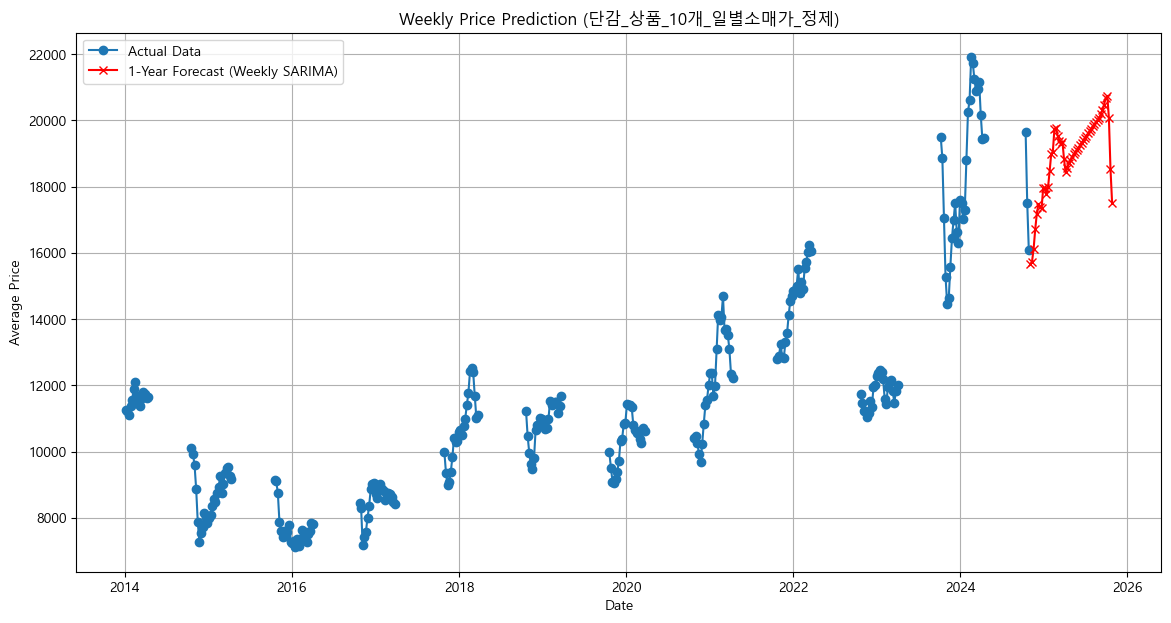

C:\Users\acorn\AppData\Local\Temp\ipykernel_4952\3834608884.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
C:\Users\acorn\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\단감_중품_10개_일별소매가_정제_과거+예측데이터.csv


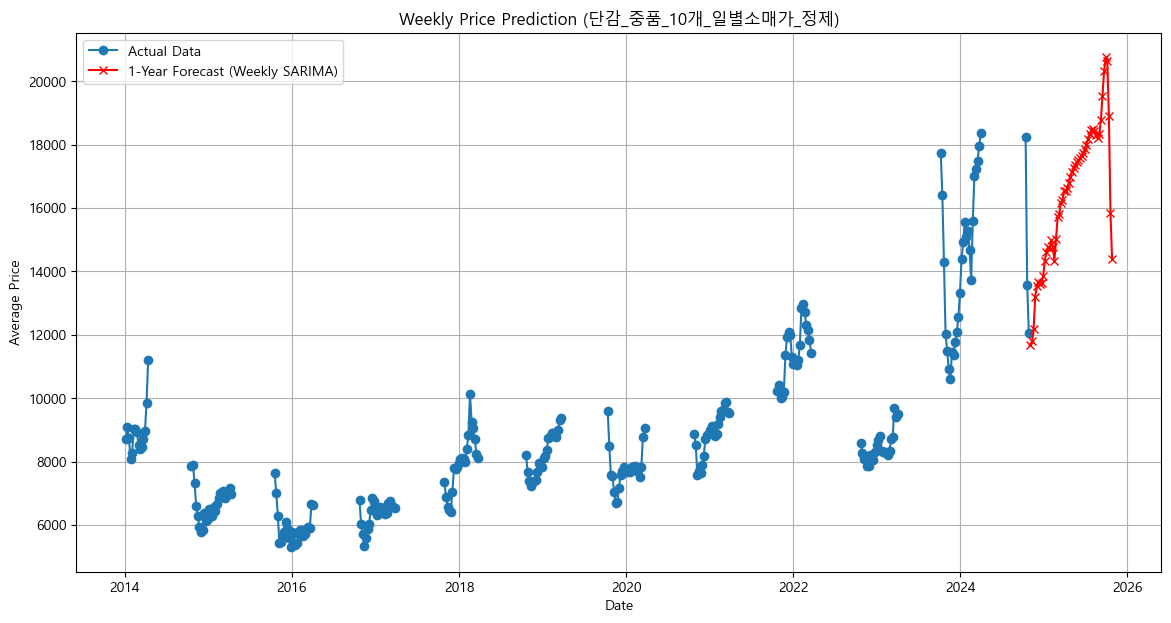

In [59]:
# 각 파일 반복 처리
for file_path in file_list:
    # 파일 이름 추출 (예: 감자_중품_100g_일별소매가)
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    
    # 데이터 로드
    data = pd.read_csv(file_path, encoding='utf-8')
    
     # 쉼표 제거 처리 (숫자 변환)
    if data['평균'].dtype == 'object':
        data['평균'] = data['평균'].str.replace(',', '').astype(float)
        
    # 날짜 변환 및 데이터 준비
    data['구분'] = pd.to_datetime(data['구분'])
    data.set_index('구분', inplace=True)
    daily_prices = data['평균']
    
    # 결측치 처리 (필요시)
    daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
    
    # 주별 평균 데이터 생성
    weekly_prices = daily_prices.resample('W').mean()
    
    # SARIMA 모델 학습
    model = SARIMAX(weekly_prices, order=(5, 1, 0), seasonal_order=(1, 1, 1, 52))
    fitted_model = model.fit()
    
    # 1년(52주) 예측
    forecast = fitted_model.get_forecast(steps=52)
    forecast_values = forecast.predicted_mean
    
    # 예측 결과를 DataFrame으로 저장
    forecast_index = pd.date_range(start=weekly_prices.index[-1] + pd.DateOffset(weeks=1), 
                                   periods=52, freq='W')
    forecast_df = pd.DataFrame({
        'Date': forecast_index,
        'Price': forecast_values.values
    })
    
    # 과거 데이터와 예측 데이터 결합
    combined_df = pd.concat([
        pd.DataFrame({'Date': weekly_prices.index, 'Price': weekly_prices.values}),  # 과거 데이터
        forecast_df  # 예측 데이터
    ])
    
    # CSV 파일로 저장
    output_file = os.path.join(output_dir, f'{file_name}_과거+예측데이터.csv')
    combined_df.to_csv(output_file, index=False, encoding='cp949')
    print(f"파일 저장 완료: {output_file}")
    
    # 시각화
    plt.figure(figsize=(14, 7))
    plt.plot(weekly_prices, label='Actual Data', marker='o')
    plt.plot(forecast_index, forecast_values, label='1-Year Forecast (Weekly SARIMA)', color='red', marker='x')
    plt.title(f'Weekly Price Prediction ({file_name})')
    plt.xlabel('Date')
    plt.ylabel('Average Price')
    plt.legend()
    plt.grid(True)
    plt.show()

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import os

# Matplotlib 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [29]:
csv_path = 'C:/Users/acorn/Documents/python/일별소매가/product_price_20241212.csv'
csv_data = pd.read_csv(csv_path, encoding='cp949')
# 결과 저장 디렉토리
output_dir = 'C:/Users/acorn/Documents/python/일별소매가/결과'
os.makedirs(output_dir, exist_ok=True)  # 디렉토리가 없으면 생성

In [31]:
# 쉼표 제거 처리 (숫자 변환)
if csv_data['평균'].dtype == 'object':
    csv_data['평균'] = csv_data['평균'].str.replace(',', '').astype(float)

# 날짜 변환
csv_data['구분'] = pd.to_datetime(csv_data['구분'])

# 품목별로 그룹화
items = csv_data['품목'].unique()  # 품목 목록 추출
grouped = csv_data.groupby('품목')  # 품목별 데이터 그룹화

# 전체 결과 저장을 위한 리스트
all_results = []

C:\Users\acorn\AppData\Local\Temp\ipykernel_12000\3675337329.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
C:\Users\acorn\AppData\Local\Temp\ipykernel_12000\3675337329.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')
C:\Users\acorn\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\acorn\AppData\Local\Temp\ipykernel_12000\3675337329.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_prices = daily_

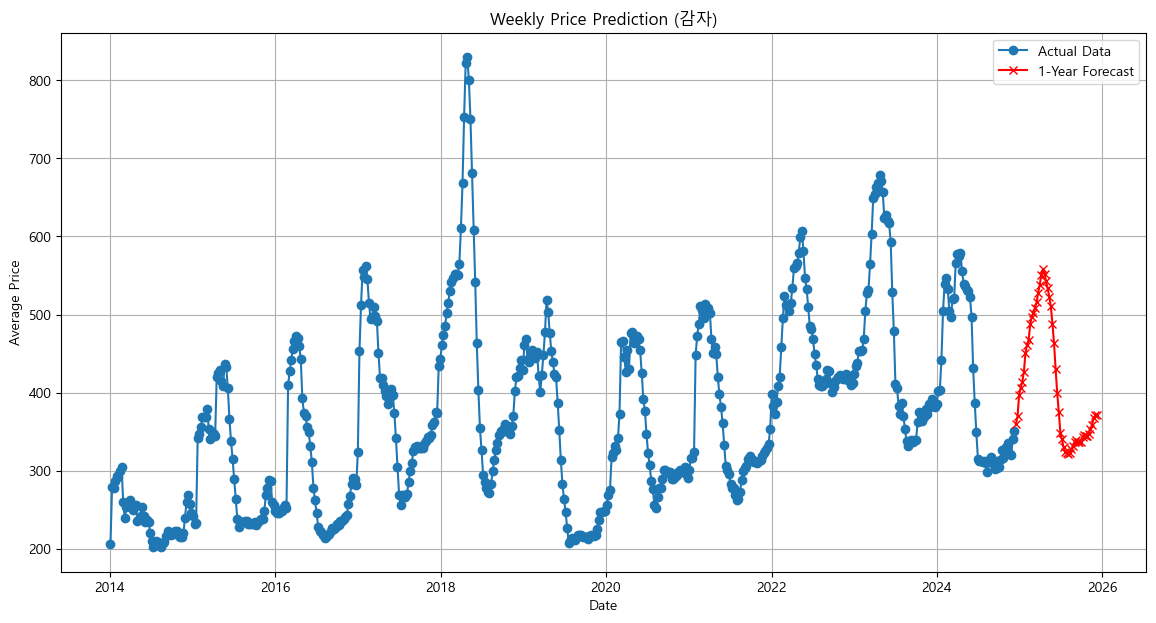

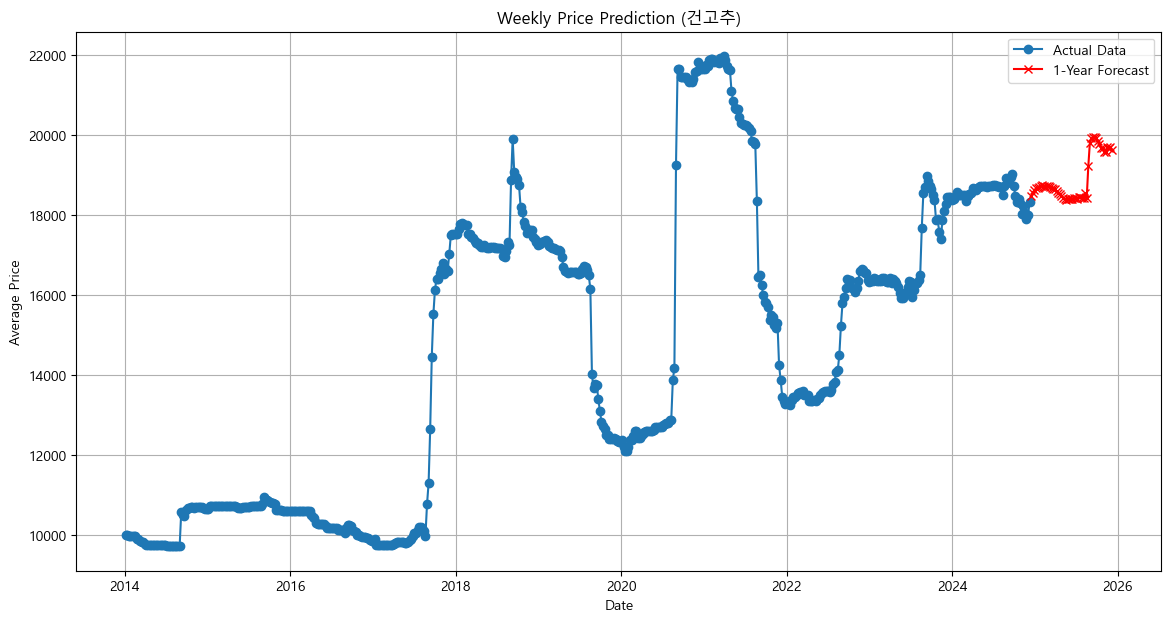

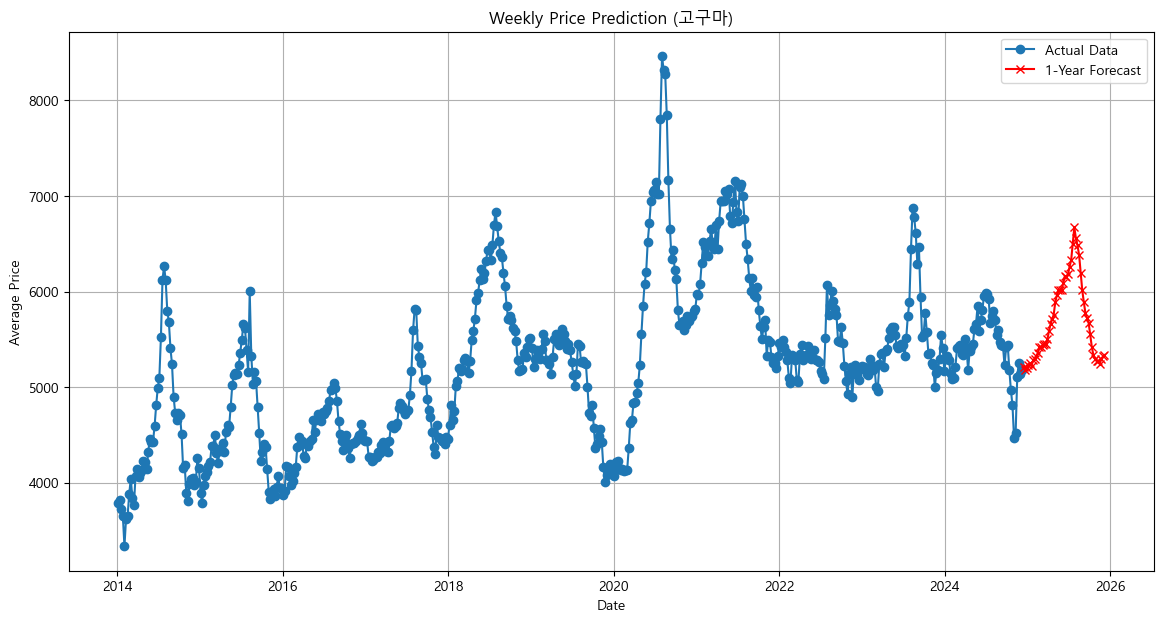

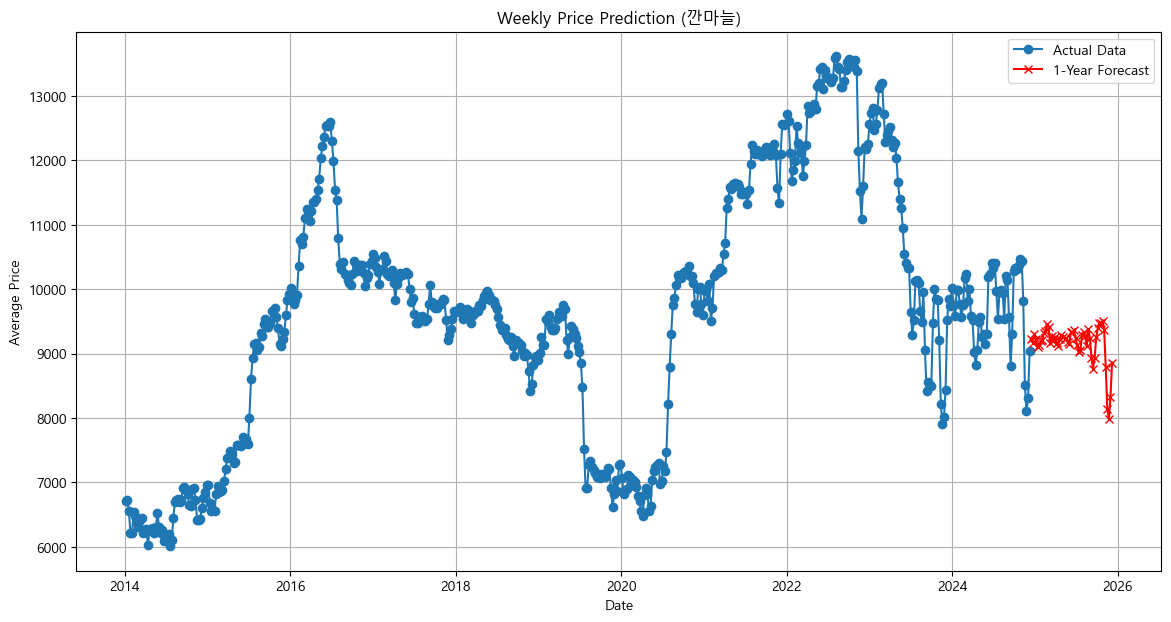

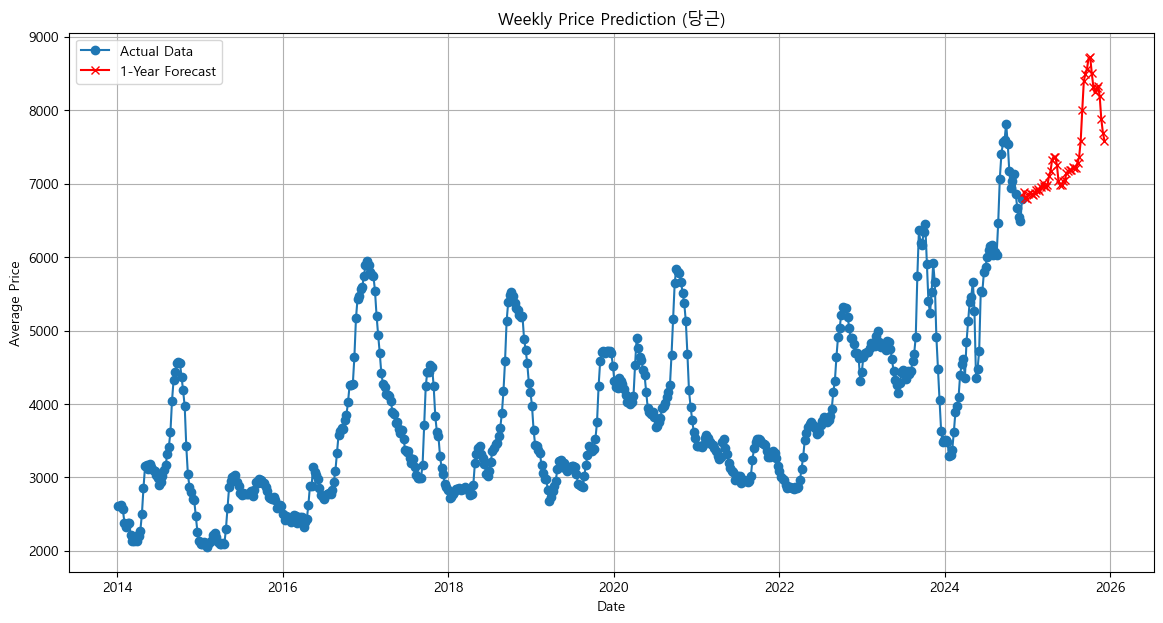

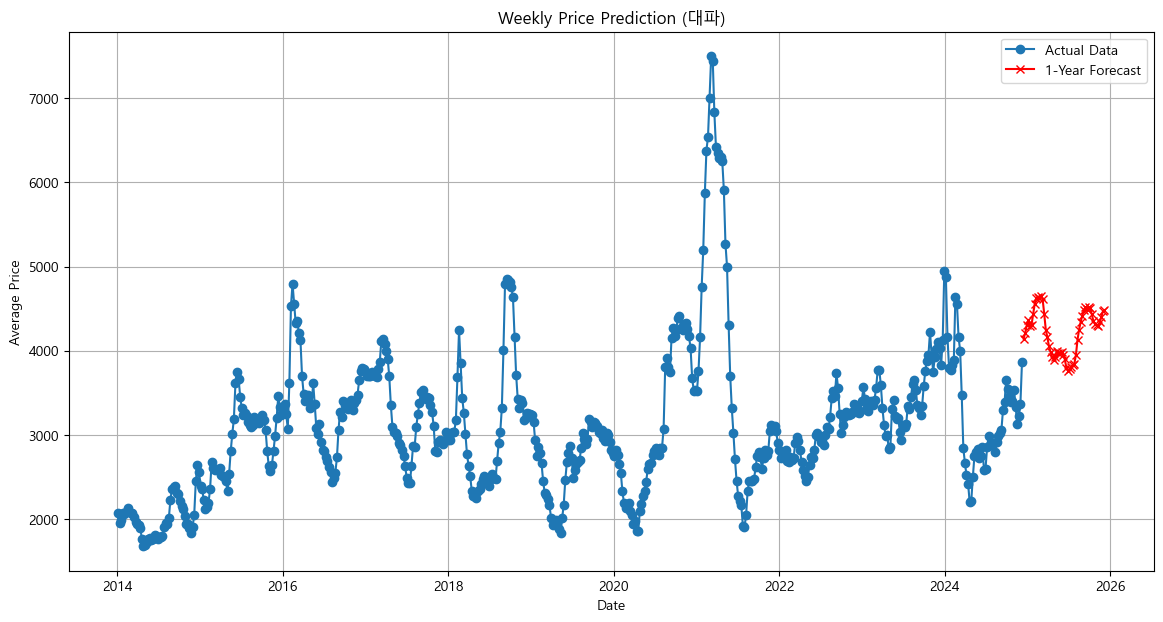

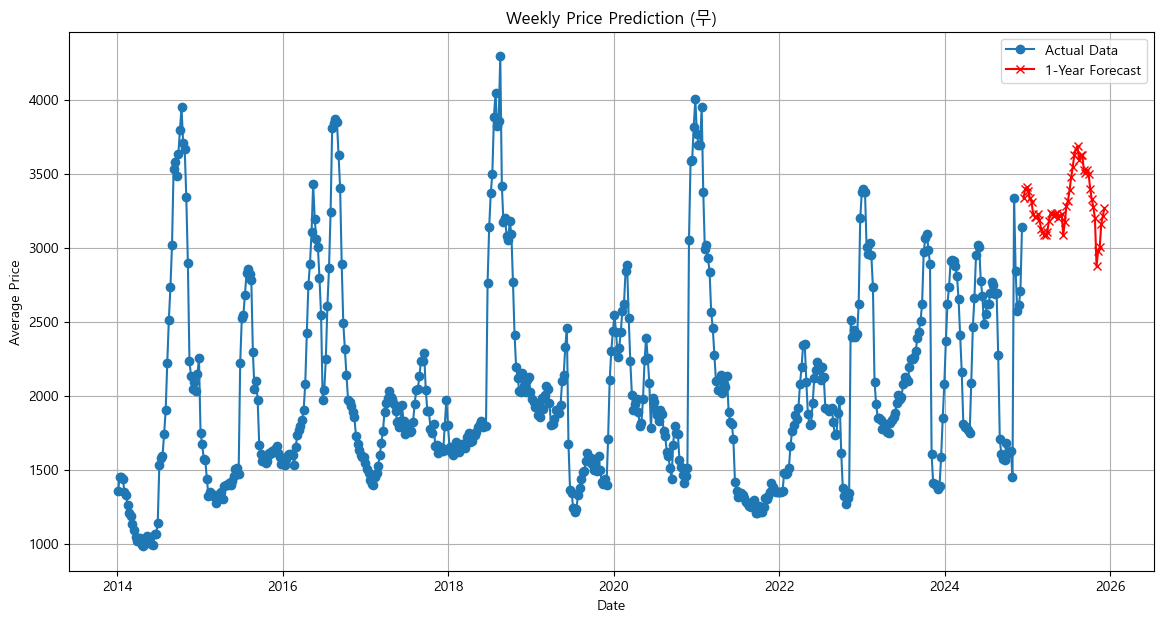

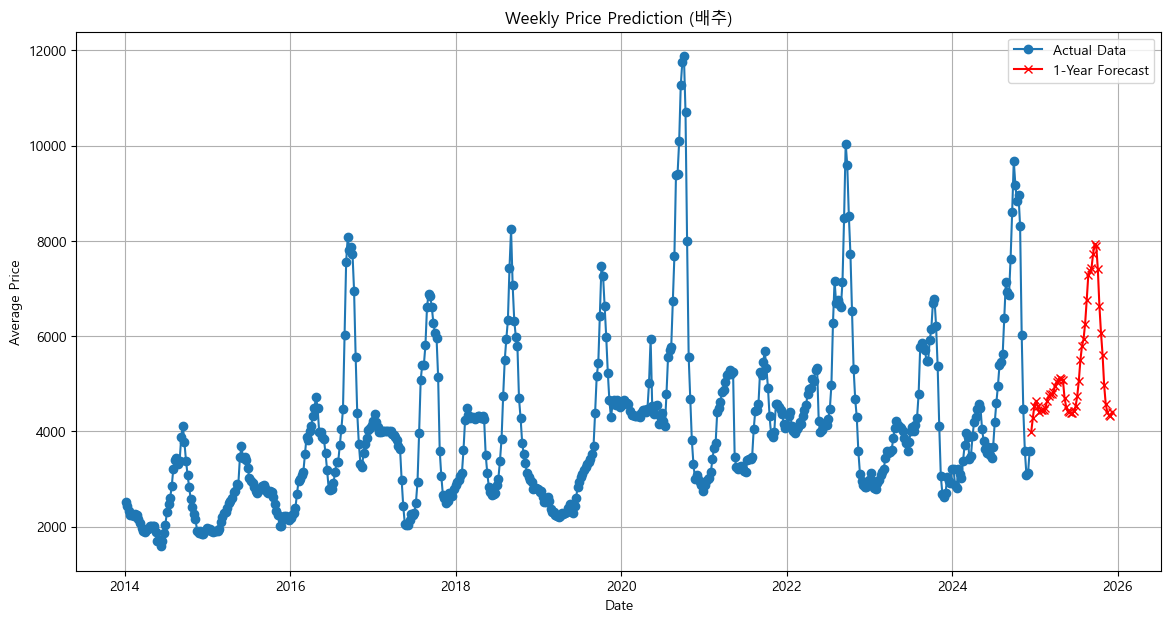

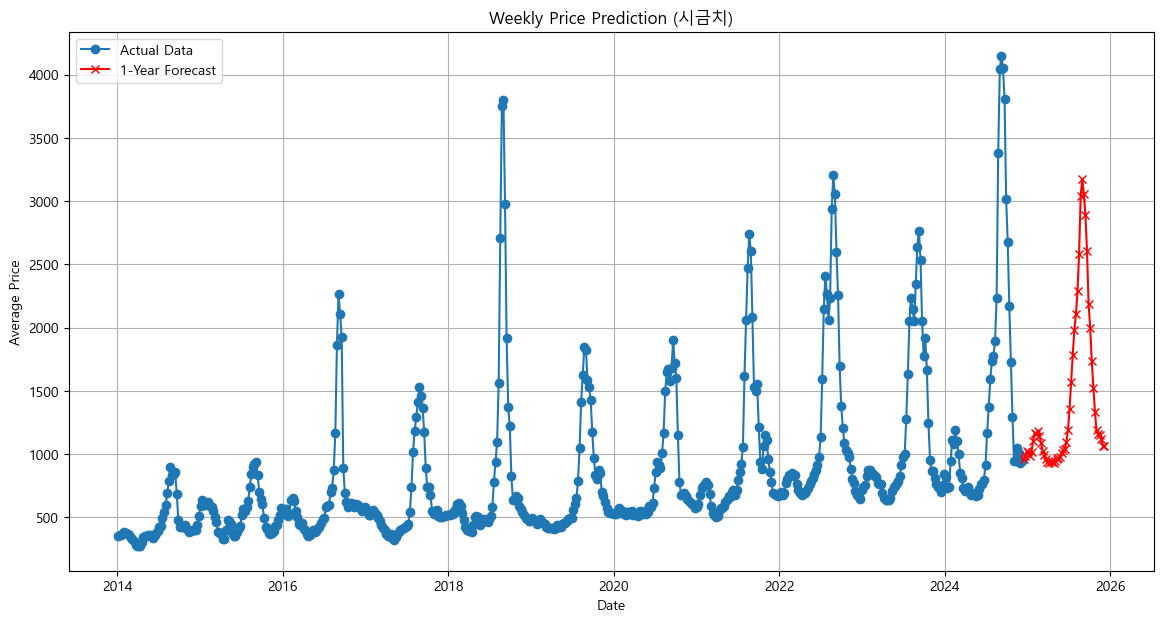

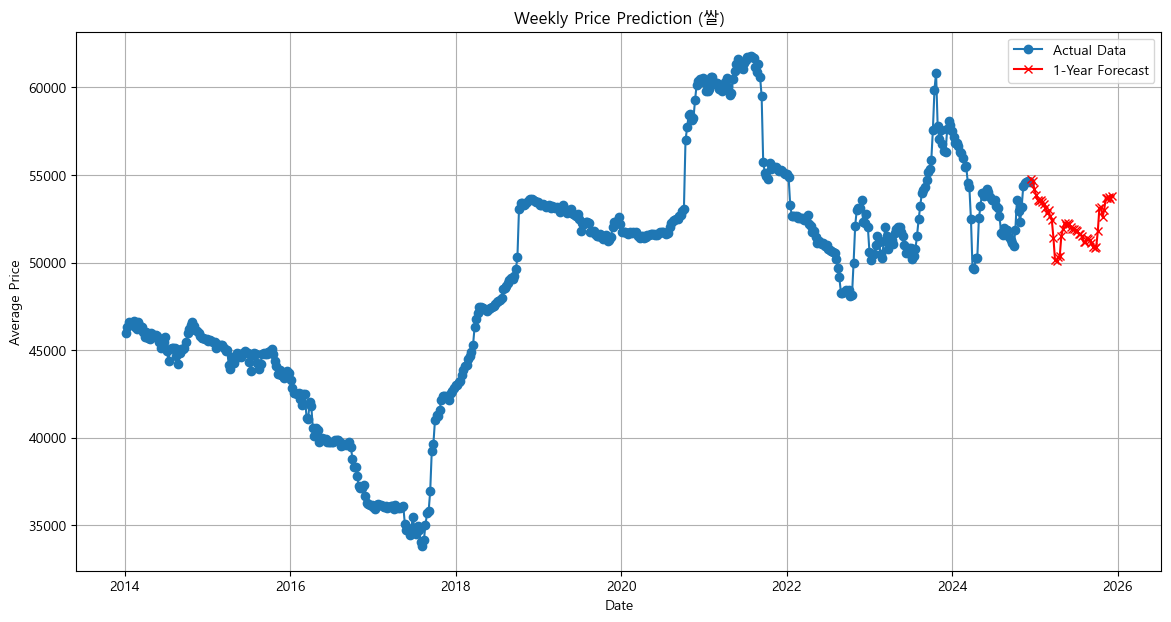

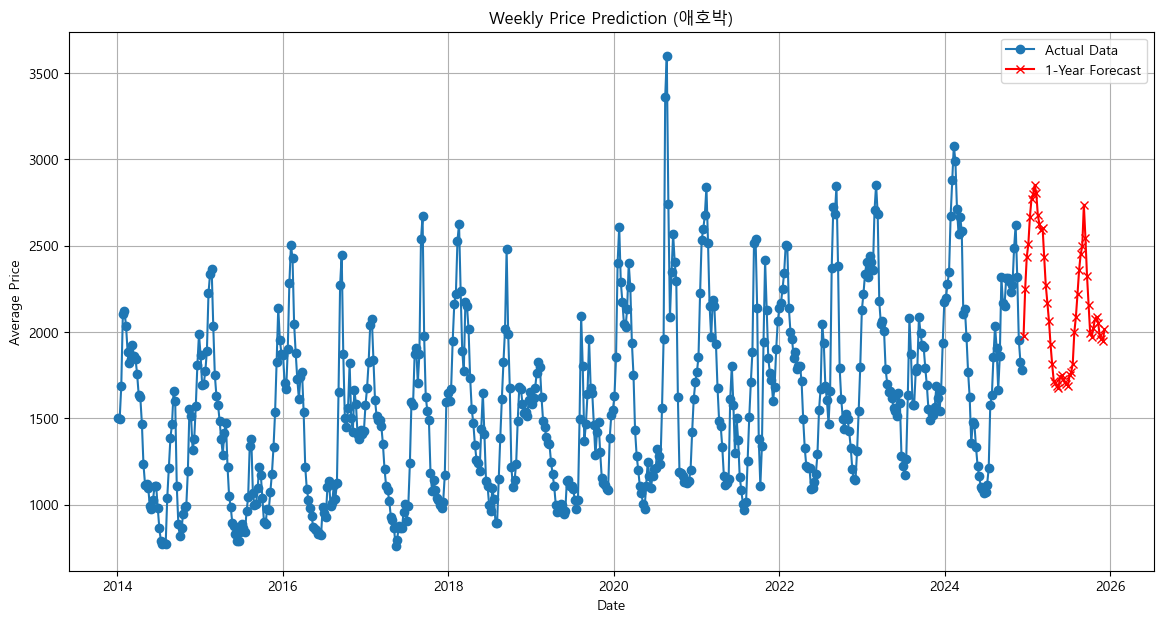

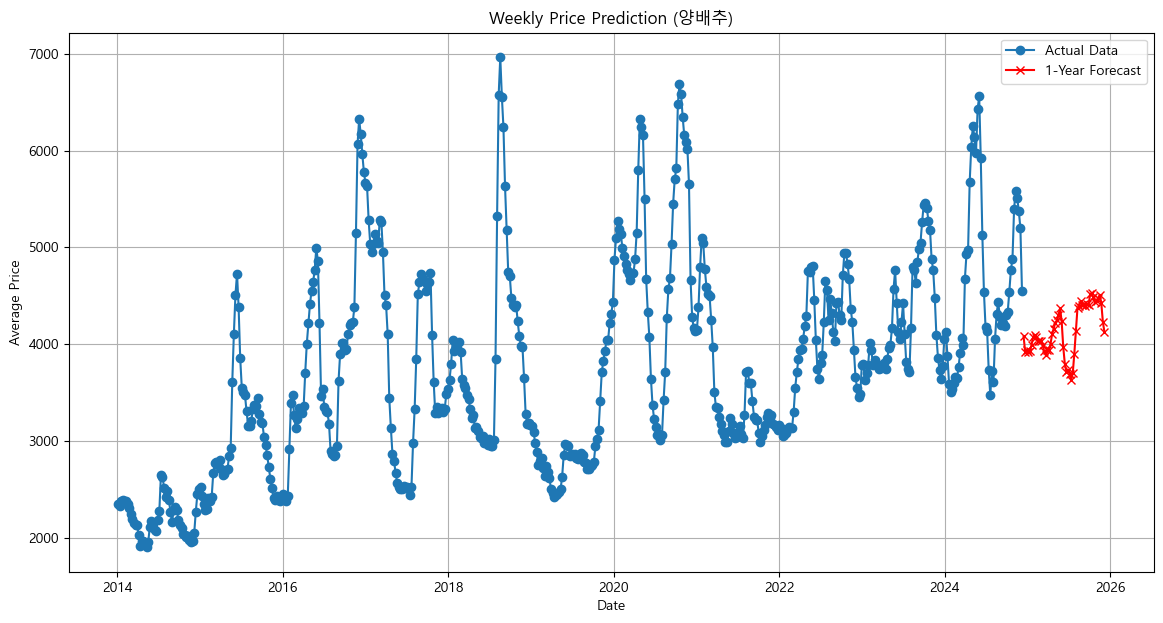

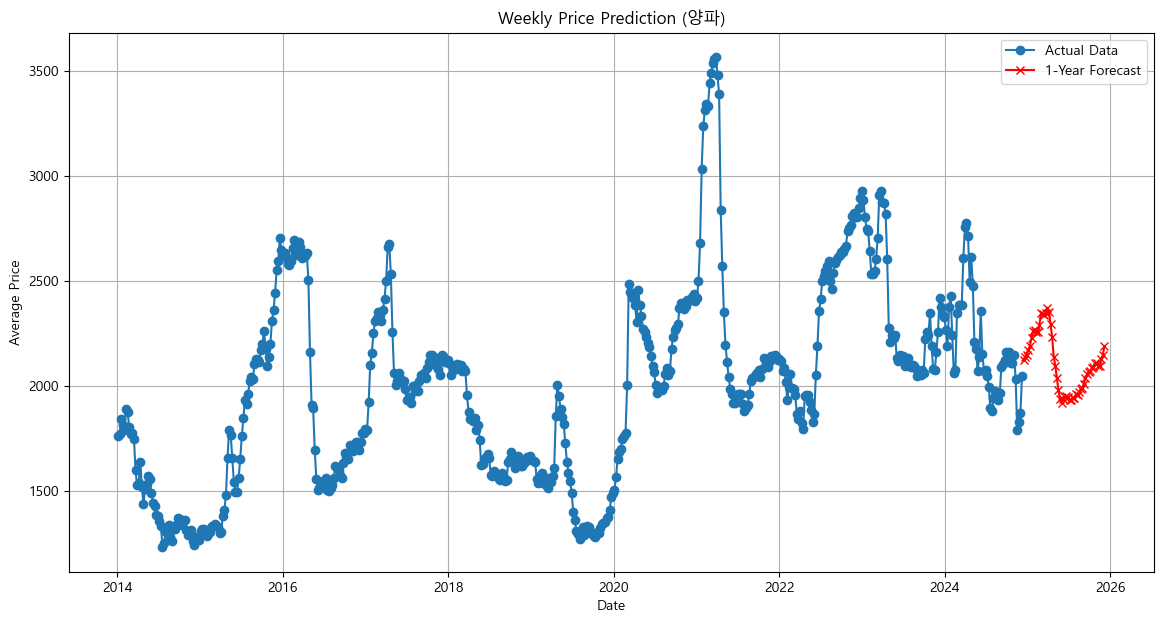

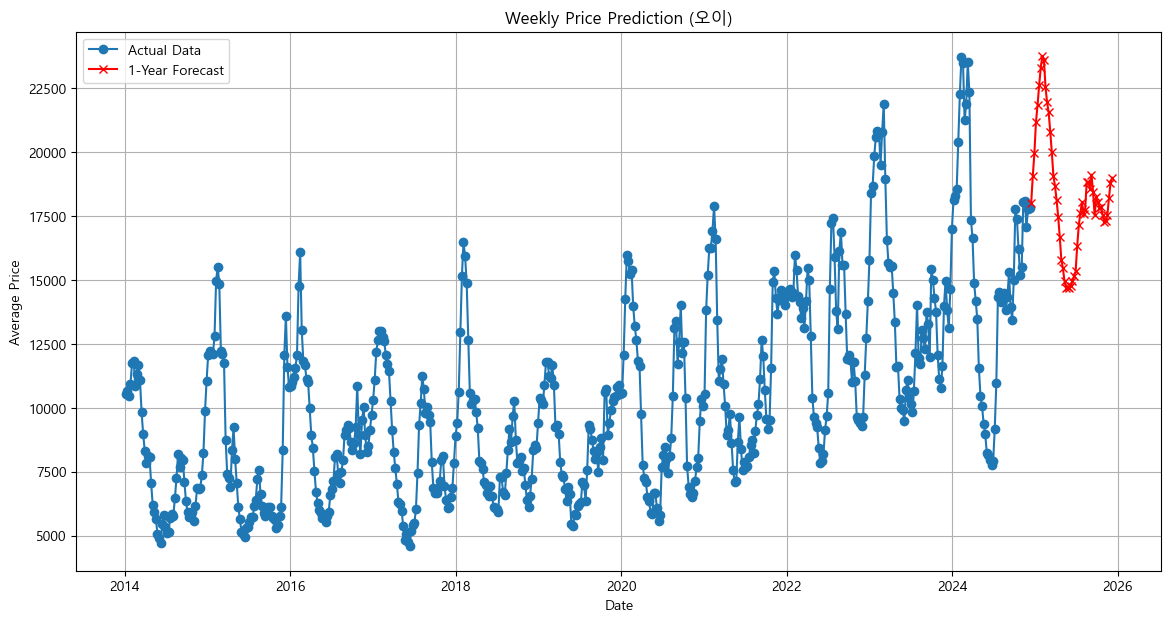

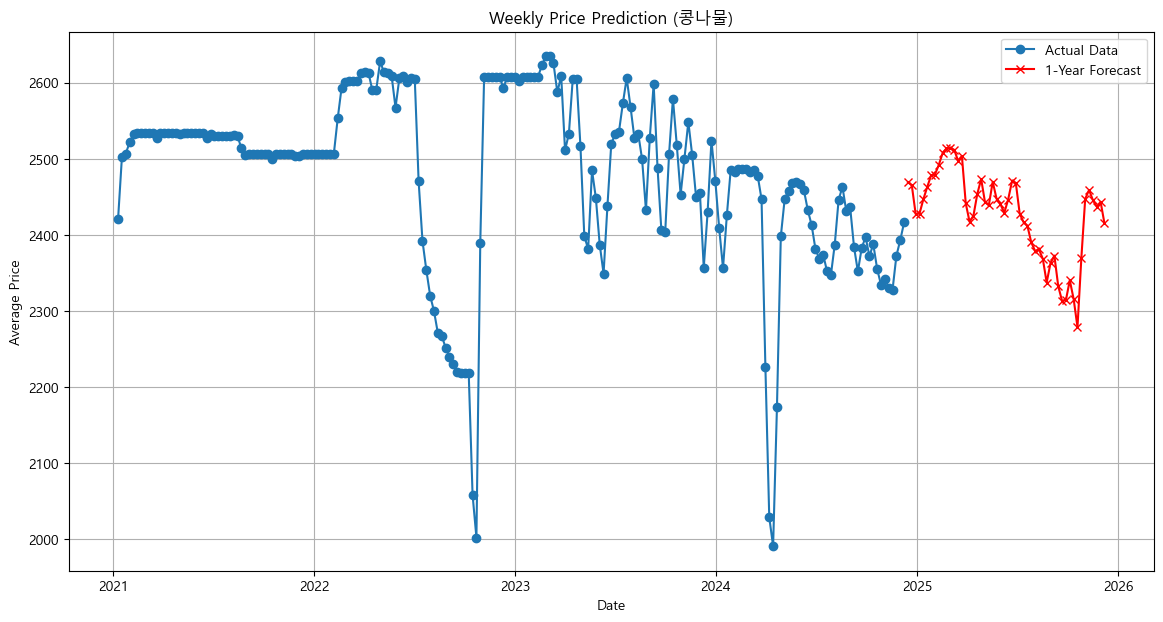

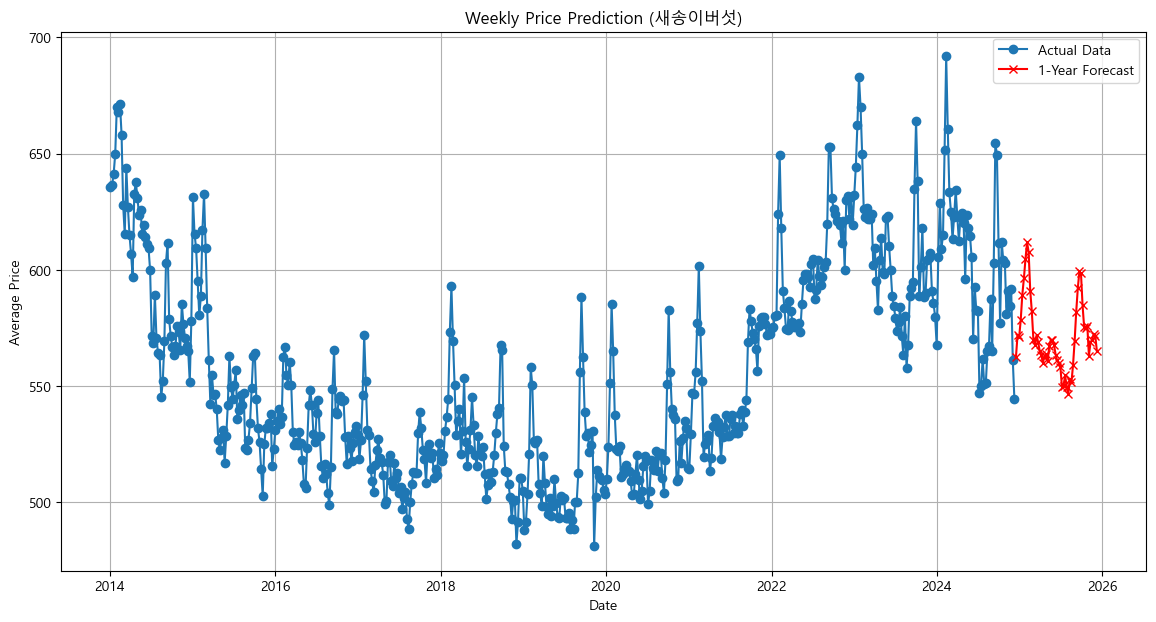

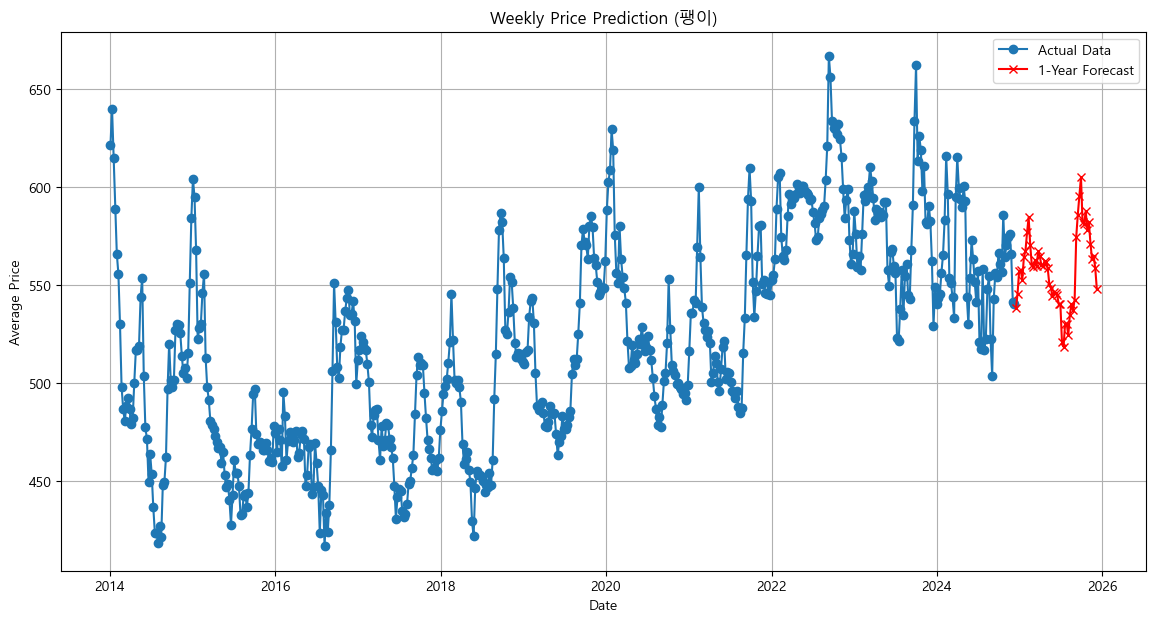

In [33]:
# SARIMA 모델 학습 및 예측
for item in items:
    # 품목별 데이터 필터링
    item_data = grouped.get_group(item)
    item_data.set_index('구분', inplace=True)
    daily_prices = item_data['평균']

    # 결측치 처리
    daily_prices = daily_prices.fillna(method='ffill').fillna(method='bfill')

    # 주별 평균 데이터 생성
    weekly_prices = daily_prices.resample('W').mean()

    # SARIMA 모델 학습
    model = SARIMAX(weekly_prices, order=(5, 1, 0), seasonal_order=(1, 1, 1, 52))
    fitted_model = model.fit()

    # 1년(52주) 예측
    forecast = fitted_model.get_forecast(steps=52)
    forecast_values = forecast.predicted_mean

    # 예측 결과를 DataFrame으로 저장
    forecast_index = pd.date_range(start=weekly_prices.index[-1] + pd.DateOffset(weeks=1), 
                                   periods=52, freq='W')
    forecast_df = pd.DataFrame({
        '구분': forecast_index,
        '평균': forecast_values.values,
        '품목': item  # 품목 추가
    })

    # 과거 데이터에 품목 컬럼 추가
    past_df = pd.DataFrame({
        '구분': weekly_prices.index,
        '평균': weekly_prices.values,
        '품목': item  # 품목 추가
    })

    # 과거 데이터와 예측 데이터 결합
    combined_df = pd.concat([past_df, forecast_df])

    # 전체 결과 리스트에 추가
    all_results.append(combined_df)

    # 시각화 (각 품목별 그래프 생성 및 저장)
    plt.figure(figsize=(14, 7))
    plt.plot(weekly_prices, label='Actual Data', marker='o')
    plt.plot(forecast_index, forecast_values, label='1-Year Forecast', color='red', marker='x')
    plt.title(f'Weekly Price Prediction ({item})')
    plt.xlabel('Date')
    plt.ylabel('Average Price')
    plt.legend()
    plt.grid(True)

In [35]:
output_file = os.path.join(output_dir, 'product_price_past_predicted_20241212.csv')

final_df = pd.concat(all_results, ignore_index=True)

# CSV 파일로 저장
final_df.to_csv(output_file, index=False, encoding='cp949')
print(f"최종 파일 저장 완료: {output_file}")

최종 파일 저장 완료: C:/Users/acorn/Documents/python/일별소매가/결과\product_price_past_predicted_20241212.csv
